In [1]:
import fastf1
import pandas as pd
import numpy as np

f1_data = fastf1.get_session(2024, "Bahrain", "Race")
f1_data_british = fastf1.get_session(2026, "British", "Race")


f1_data.load()
f1_data_british.load()

req         WARNING 	DEFAULT CACHE ENABLED! (212.73 MB) C:\Users\Admin\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', 

In [2]:
laps = f1_data.laps
laps_british = f1_data_british.laps
tyre_data_british = f1_data_british

print(laps.shape)
print(laps_british.shape)



(1129, 31)
(1113, 31)


In [3]:
f1_data_british

2026 Season Round 9: British Grand Prix - Race

In [4]:
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:01:37.489000,VER,1,0 days 00:01:37.284000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.266000,...,False,Red Bull Racing,0 days 00:59:59.911000,2024-03-02 15:03:42.342,12,1.0,False,,False,False
1,0 days 01:03:13.785000,VER,1,0 days 00:01:36.296000,2.0,1.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:41.661000,...,False,Red Bull Racing,0 days 01:01:37.489000,2024-03-02 15:05:19.920,1,1.0,False,,False,True
2,0 days 01:04:50.538000,VER,1,0 days 00:01:36.753000,3.0,1.0,NaT,NaT,0 days 00:00:30.999000,0 days 00:00:41.966000,...,False,Red Bull Racing,0 days 01:03:13.785000,2024-03-02 15:06:56.216,1,1.0,False,,False,True
3,0 days 01:06:27.185000,VER,1,0 days 00:01:36.647000,4.0,1.0,NaT,NaT,0 days 00:00:30.931000,0 days 00:00:41.892000,...,False,Red Bull Racing,0 days 01:04:50.538000,2024-03-02 15:08:32.969,1,1.0,False,,False,True
4,0 days 01:08:04.358000,VER,1,0 days 00:01:37.173000,5.0,1.0,NaT,NaT,0 days 00:00:31.255000,0 days 00:00:42.056000,...,False,Red Bull Racing,0 days 01:06:27.185000,2024-03-02 15:10:09.616,1,1.0,False,,False,True


In [5]:
print(laps.columns.tolist())

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [6]:
f1_data

2024 Season Round 1: Bahrain Grand Prix - Race

In [7]:
laps.info()

<class 'fastf1.core.Laps'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1129 non-null   timedelta64[ns]
 1   Driver              1129 non-null   object         
 2   DriverNumber        1129 non-null   object         
 3   LapTime             1127 non-null   timedelta64[ns]
 4   LapNumber           1129 non-null   float64        
 5   Stint               1129 non-null   float64        
 6   PitOutTime          43 non-null     timedelta64[ns]
 7   PitInTime           43 non-null     timedelta64[ns]
 8   Sector1Time         1108 non-null   timedelta64[ns]
 9   Sector2Time         1129 non-null   timedelta64[ns]
 10  Sector3Time         1129 non-null   timedelta64[ns]
 11  Sector1SessionTime  1107 non-null   timedelta64[ns]
 12  Sector2SessionTime  1129 non-null   timedelta64[ns]
 13  Sector3SessionTime  1129 non-null   timedelt

In [8]:
laps.isna().sum()


Time                     0
Driver                   0
DriverNumber             0
LapTime                  2
LapNumber                0
Stint                    0
PitOutTime            1086
PitInTime             1086
Sector1Time             21
Sector2Time              0
Sector3Time              0
Sector1SessionTime      22
Sector2SessionTime       0
Sector3SessionTime       0
SpeedI1                  0
SpeedI2                  0
SpeedFL                 43
SpeedST                  0
IsPersonalBest           0
Compound                 0
TyreLife                 0
FreshTyre                0
Team                     0
LapStartTime             0
LapStartDate             0
TrackStatus              0
Position                 0
Deleted                  0
DeletedReason            0
FastF1Generated          0
IsAccurate               0
dtype: int64

In [9]:
laps['Compound'].value_counts(dropna=False)

Compound
HARD    791
SOFT    338
Name: count, dtype: int64

In [10]:
laps["Driver"].value_counts()

Driver
VER    57
PER    57
SAI    57
LEC    57
RUS    57
NOR    57
HAM    57
PIA    57
ALO    57
STR    57
ZHO    56
MAG    56
RIC    56
TSU    56
ALB    56
HUL    56
OCO    56
GAS    56
BOT    56
SAR    55
Name: count, dtype: int64

In [11]:
print(type(laps))

<class 'fastf1.core.Laps'>


In [12]:
laps.groupby('Driver')['LapNumber'].max().sort_values(ascending=False)

Driver
ALO    57.0
PER    57.0
LEC    57.0
HAM    57.0
STR    57.0
VER    57.0
SAI    57.0
NOR    57.0
PIA    57.0
RUS    57.0
ALB    56.0
BOT    56.0
GAS    56.0
OCO    56.0
HUL    56.0
MAG    56.0
TSU    56.0
RIC    56.0
ZHO    56.0
SAR    55.0
Name: LapNumber, dtype: float64

In [13]:
laps.groupby("Driver")["Position"].last().sort_values()

Driver
VER     1.0
PER     2.0
SAI     3.0
LEC     4.0
RUS     5.0
NOR     6.0
HAM     7.0
PIA     8.0
ALO     9.0
STR    10.0
ZHO    11.0
MAG    12.0
RIC    13.0
TSU    14.0
ALB    15.0
HUL    16.0
OCO    17.0
GAS    18.0
BOT    19.0
SAR    20.0
Name: Position, dtype: float64

In [14]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [15]:
laps[['Driver','LapNumber','Compound','TyreLife','FreshTyre']]

,Driver,LapNumber,Compound,TyreLife,FreshTyre
0,VER,1.0,SOFT,4.0,False
1,VER,2.0,SOFT,5.0,False
2,VER,3.0,SOFT,6.0,False
3,VER,4.0,SOFT,7.0,False
4,VER,5.0,SOFT,8.0,False
...,...,...,...,...,...
1124,SAR,51.0,SOFT,11.0,True
1125,SAR,52.0,SOFT,12.0,True
1126,SAR,53.0,SOFT,13.0,True
1127,SAR,54.0,SOFT,14.0,True


In [16]:
laps['Compound'].value_counts()

Compound
HARD    791
SOFT    338
Name: count, dtype: int64

In [17]:
laps['TyreLife'].value_counts()

TyreLife
4.0     62
5.0     62
6.0     62
7.0     62
8.0     62
9.0     62
10.0    60
11.0    58
12.0    57
13.0    53
14.0    52
3.0     52
2.0     52
1.0     52
15.0    49
16.0    44
17.0    40
18.0    39
19.0    35
20.0    32
21.0    24
22.0    17
23.0    13
24.0    10
25.0     6
26.0     6
27.0     2
28.0     2
29.0     1
30.0     1
Name: count, dtype: int64

In [18]:
laps.groupby("Compound")["TyreLife"].agg(["min", "max", "mean", "count"])

,min,max,mean,count
Compound,,,,
HARD,1.0,30.0,11.510746,791
SOFT,1.0,21.0,8.822485,338


In [19]:
laps['Stint']

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1124    4.0
1125    4.0
1126    4.0
1127    4.0
1128    4.0
Name: Stint, Length: 1129, dtype: float64

In [20]:
laps.groupby(["Driver", "Stint", "Compound"])["TyreLife"].agg(["min", "max", "count"]).T

Driver     ALB               ALO               BOT               GAS  ...  \
Stint      1.0   2.0   3.0   1.0   2.0   3.0   1.0   2.0   3.0   1.0  ...   
Compound  SOFT  HARD  HARD  SOFT  HARD  HARD  SOFT  HARD  HARD  SOFT  ...   
min        1.0   1.0   1.0   4.0   1.0   1.0   1.0   1.0   1.0   1.0  ...   
max       15.0  21.0  20.0  18.0  26.0  16.0  12.0  18.0  26.0  12.0  ...   
count     15.0  21.0  20.0  15.0  26.0  16.0  12.0  18.0  26.0  12.0  ...   

Driver     STR   TSU               VER              ZHO              
Stint      3.0   1.0   2.0   3.0   1.0   2.0   3.0  1.0   2.0   3.0  
Compound  HARD  SOFT  HARD  HARD  SOFT  HARD  SOFT SOFT  HARD  HARD  
min        1.0   1.0   1.0   1.0   4.0   1.0   1.0  1.0   1.0   1.0  
max       30.0  14.0  20.0  22.0  20.0  20.0  20.0  9.0  19.0  28.0  
count     30.0  14.0  20.0  22.0  17.0  20.0  20.0  9.0  19.0  28.0  

[3 rows x 63 columns]

In [21]:
# Your biggest Pandas trick

# Don't memorize 50 Pandas commands.

# Learn these questions → operations relationships:

# Question you want to answer	Typical operation
# How many?   - 	count(), value_counts()
# What categories exist?   - 	unique(), value_counts()
# What is the average?   - 	mean()
# What is the minimum/maximum?   - 	min(), max()
# How does X differ between groups?   - 	groupby()
# Show me only certain rows   - 	filtering
# Compare two datasets   - 	merge()
# Create a new variable	column assignment
# Relationship between variables   - 	correlation / plots
# Distribution of something   - 	histogram / descriptive statistics
# Find unusual values   - 	outlier analysis
# Change data structure   - 	pivot_table()

# You don't need to memorize syntax yet.

# You need to recognize:

# Question → appropriate analytical operation.

In [22]:
laps.columns     

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [23]:

laps[['Stint','Compound','TyreLife','Position']]

,Stint,Compound,TyreLife,Position
0,1.0,SOFT,4.0,1.0
1,1.0,SOFT,5.0,1.0
2,1.0,SOFT,6.0,1.0
3,1.0,SOFT,7.0,1.0
4,1.0,SOFT,8.0,1.0
...,...,...,...,...
1124,4.0,SOFT,11.0,20.0
1125,4.0,SOFT,12.0,20.0
1126,4.0,SOFT,13.0,20.0
1127,4.0,SOFT,14.0,20.0


In [24]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [25]:
laps[['Time','Driver','LapTime','LapNumber','SpeedI1','SpeedI2','SpeedFL','SpeedST','Compound','TyreLife','FreshTyre']]

,Time,Driver,LapTime,LapNumber,SpeedI1,SpeedI2,SpeedFL,SpeedST,Compound,TyreLife,FreshTyre
0,0 days 01:01:37.489000,VER,0 days 00:01:37.284000,1.0,234.0,250.0,276.0,251.0,SOFT,4.0,False
1,0 days 01:03:13.785000,VER,0 days 00:01:36.296000,2.0,232.0,248.0,276.0,287.0,SOFT,5.0,False
2,0 days 01:04:50.538000,VER,0 days 00:01:36.753000,3.0,231.0,243.0,276.0,290.0,SOFT,6.0,False
3,0 days 01:06:27.185000,VER,0 days 00:01:36.647000,4.0,233.0,253.0,276.0,290.0,SOFT,7.0,False
4,0 days 01:08:04.358000,VER,0 days 00:01:37.173000,5.0,231.0,245.0,276.0,289.0,SOFT,8.0,False
...,...,...,...,...,...,...,...,...,...,...,...
1124,0 days 02:25:37.835000,SAR,0 days 00:01:35.972000,51.0,233.0,261.0,281.0,291.0,SOFT,11.0,True
1125,0 days 02:27:13.822000,SAR,0 days 00:01:35.987000,52.0,233.0,262.0,281.0,292.0,SOFT,12.0,True
1126,0 days 02:28:49.910000,SAR,0 days 00:01:36.088000,53.0,232.0,261.0,281.0,292.0,SOFT,13.0,True
1127,0 days 02:30:29.524000,SAR,0 days 00:01:39.614000,54.0,185.0,261.0,282.0,292.0,SOFT,14.0,True


In [26]:
laps_british.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [27]:
# so now i am making my own thesis and in that i ll be studying about the tyre and how the tyre affect the pit stoop and how the tyre health affect the lap time and performance

In [28]:
# here is the thesis for and about the tyre.. 

# HOW TYRE AFFECT THE LAP TIME -->

# to make this model we have laptime , speed , sector time , compound and tyre life. 

# this are three type of tyres -->

# 1. Soft -> grip ⬇️, tyre life ⬆️, warm up⬆️
# 2. Medium -> grip➕, life➕, warm up➕
# 3. Hard -> grip⬇️, life⬆️, warm up⬇️


# Things that affect the tyres are -->
# 1. circuit
# 2. temperature
# 3. trye prep.

# this is how temperature affect the tyre -->

# too cold --> low grip⬇️, graning⬆️
# optimal  --> best grip
# too hot  --> grip loss, degreadation⬆️

# so if the tyre is too hot the performance start decressing gradually 

# if the tyre is cold then a driver can look some time corner due to low grip

# Temperature 

# tyre age != degradation

# more the tyre age is not always more degradation.

# degradation = time loss 

# DEGRADATION DEPENDS ON = SUM( AGE, COMPOUND, TRACK, TEMP, LOAD , DRIVING  )

# so the tyre can not be the only reason for the loss in race pace.and


# now letss see on what factors laptime , and race pace depends on -->

# laptime --> SUM( FUEL, TRYE, TRAFFFIC , TRACK , DRIVER, WEATHER ) OPPTIONAL ( ENERGY + ERROR )

# HOW NEW AND OLD TYRE AFFECT LAP TIME -->

# on broader level new tyre are always better , but not always

# degradation is much more complcated then  it look 

# WEATHER ->
# This is how weather affect tyre and lap performance 


# hot condition comes with ovrerheating⬆️, Thermal degradation⬆️, Tyre management⬆️
# cold condition comes with warm up⬆️, grip⬇️, granning⬇️


# BASIC STATERGY --> 

# UNDERCUT --> UNDERCIT IS WHEN YOU PIT EARLIER GET FRESHER TYRE AND GAIN POSITION WHEN OPP PITS

# OVERCUT  --> DRIVER STAYS OUT IN CLEAN AIR AND GAIN THE TIME FROM THE OPPOSITION TO PIT, AND GAIN TRACK POSITION

# INPUTS WE HAVE -->

# TYRE ->        WEATHER ->       race ->      
# COMPOUND,       air temp        laps
# AGE,            track temp      remaining lap
# ESTIMATED DEG,  rain            pos
# TEMP,           humidity        gap
# PRESSUE,                        traffic
# CONDITION,                      sc/vsc
#                                 competiton

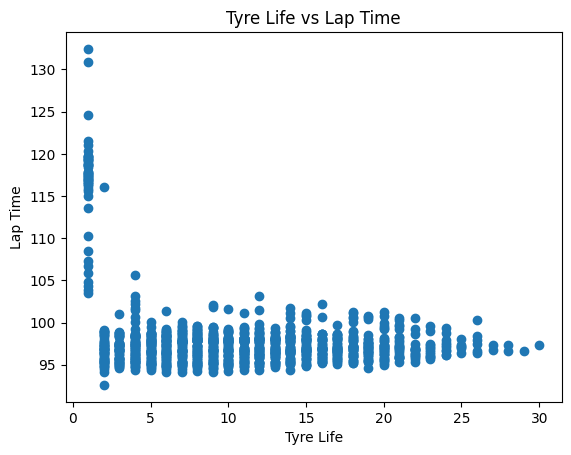

In [29]:
# tyre life vs lap time scartter plot graph

# the lap time is not in seconds we need to convert it 

laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

import matplotlib.pyplot as plt

plt.scatter(laps['TyreLife'], laps['LapTimeSeconds'])

plt.xlabel('Tyre Life')
plt.ylabel('Lap Time')
plt.title('Tyre Life vs Lap Time')

plt.show()

In [30]:
ver_laps = laps[laps['Driver'] == 'VER']

ver_laps.columns


Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [31]:
ver_laps[['LapNumber',
          'TyreLife']]

,LapNumber,TyreLife
0,1.0,4.0
1,2.0,5.0
2,3.0,6.0
3,4.0,7.0
4,5.0,8.0
5,6.0,9.0
6,7.0,10.0
7,8.0,11.0
8,9.0,12.0
9,10.0,13.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_30028\3752750795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()


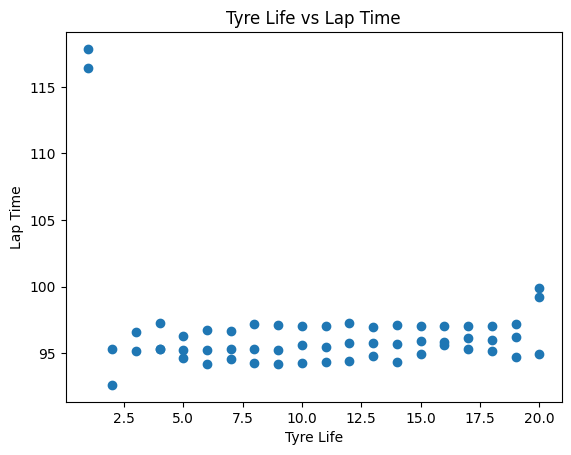

In [32]:

ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()

import matplotlib.pyplot as plt

plt.scatter(ver_laps['TyreLife'], ver_laps['LapTimeSeconds'])

plt.xlabel('Tyre Life')
plt.ylabel('Lap Time')
plt.title('Tyre Life vs Lap Time')

plt.show()

In [33]:
ver_laps[['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'Position']]

,LapNumber,LapTime,Compound,TyreLife,Stint,Position
0,1.0,0 days 00:01:37.284000,SOFT,4.0,1.0,1.0
1,2.0,0 days 00:01:36.296000,SOFT,5.0,1.0,1.0
2,3.0,0 days 00:01:36.753000,SOFT,6.0,1.0,1.0
3,4.0,0 days 00:01:36.647000,SOFT,7.0,1.0,1.0
4,5.0,0 days 00:01:37.173000,SOFT,8.0,1.0,1.0
5,6.0,0 days 00:01:37.092000,SOFT,9.0,1.0,1.0
6,7.0,0 days 00:01:37.038000,SOFT,10.0,1.0,1.0
7,8.0,0 days 00:01:37.024000,SOFT,11.0,1.0,1.0
8,9.0,0 days 00:01:37.229000,SOFT,12.0,1.0,1.0
9,10.0,0 days 00:01:36.960000,SOFT,13.0,1.0,1.0


In [34]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [35]:
ver_laps['Position']

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
23    1.0
24    1.0
25    1.0
26    1.0
27    1.0
28    1.0
29    1.0
30    1.0
31    1.0
32    1.0
33    1.0
34    1.0
35    1.0
36    1.0
37    1.0
38    1.0
39    1.0
40    1.0
41    1.0
42    1.0
43    1.0
44    1.0
45    1.0
46    1.0
47    1.0
48    1.0
49    1.0
50    1.0
51    1.0
52    1.0
53    1.0
54    1.0
55    1.0
56    1.0
Name: Position, dtype: float64

In [36]:
# ver_laps['LapTime'] = ver_laps['LapTime'].dt.total_seconds()

ver_laps[['Compound','LapTime']].describe()

,LapTime
count,57
mean,0 days 00:01:36.574421052
std,0 days 00:00:04.158272348
min,0 days 00:01:32.608000
25%,0 days 00:01:35.160000
50%,0 days 00:01:35.679000
75%,0 days 00:01:37.024000
max,0 days 00:01:57.854000


In [37]:
# ver_laps.boxplot(
#     column = 'LapTime',

#     by='Compound',
#     figsize=(10,8)
# )

# plt.title('Verstappen Lap Time Distribution by Tyre Compound')
# plt.suptitle('')
# plt.xlabel('Tyre Compound')
# plt.ylabel('Lap Time (seconds)')
# plt.show()


In [38]:
# # so the out put can be little confusing by little for many of the normal ppl , here we can see the median for the soft is above 96 but for the hards  it is 95.5 but to understand here we have to consider multiple thing for the hiiger median for faster tyre and it includs the race start compounds nand, trafic and fuel weight , race start battle and many thing other factors but in this race ver started on first and ended on first .

# so i think rthe reason for the slightly slower time for the soft are the pit stop and race start , outliers . and trafic while passing the lapped cars 

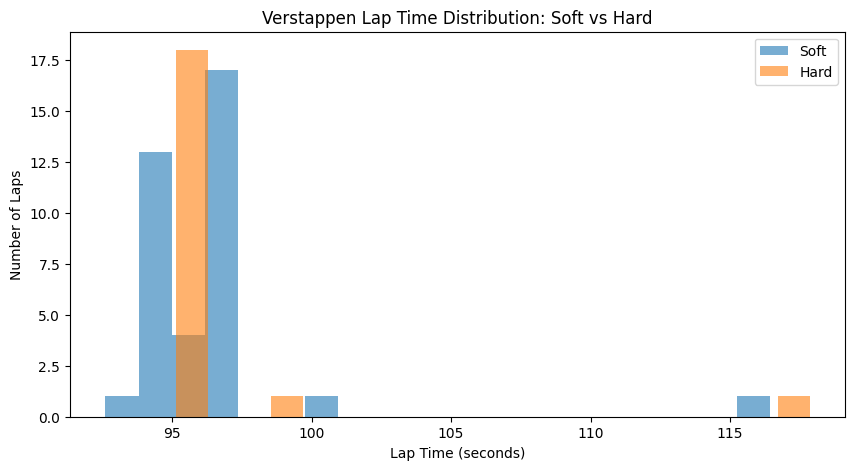

In [39]:
plt.figure(figsize=(10, 5))

ver_laps[ver_laps['Compound'] == 'SOFT']['LapTimeSeconds'].plot(
    kind='hist',
    bins=20,
    alpha=0.6,
    label='Soft'
)

ver_laps[ver_laps['Compound'] == 'HARD']['LapTimeSeconds'].plot(
    kind='hist',
    bins=20,
    alpha=0.6,
    label='Hard'
)

plt.title('Verstappen Lap Time Distribution: Soft vs Hard')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Number of Laps')
plt.legend()
plt.show()

In [40]:
# i had one doubth in this , the sets of tyre we start with are difrfrent from typre we pit , what do i mean is that ver started with the soft tyre and then he made a 2 pits stop one for the hard and then for the soft so what ma trying to say is tha 
# the first set of soft acts diffrent then the 2nd sets , and yes that can affect the lap time as well in this distrbutui  graph we can slightly see that the one sets of soft are faster and other are littler slower


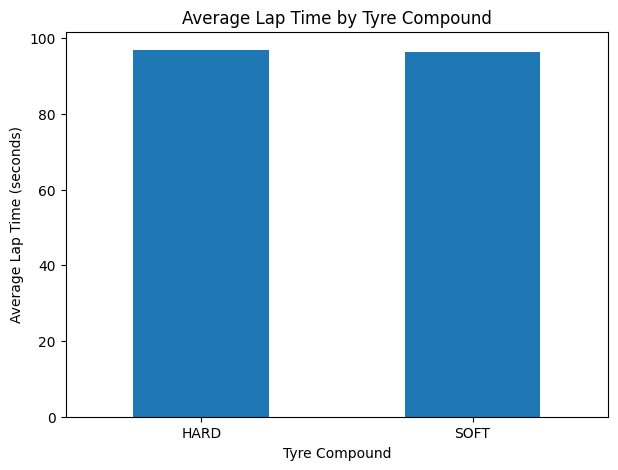

In [41]:
average_laptime = ver_laps.groupby('Compound')['LapTimeSeconds'].mean()

average_laptime

average_laptime.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Average Lap Time by Tyre Compound')
plt.xlabel('Tyre Compound')
plt.ylabel('Average Lap Time (seconds)')
plt.xticks(rotation=0)
plt.show()

In [42]:
# so in this race verstappan was alreay on pole so he has face no such fighting and defending so both the lap time are quite similar

In [43]:
ver_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [44]:
ver_laps[['PitInTime','PitOutTime','TrackStatus']]

,PitInTime,PitOutTime,TrackStatus
0,NaT,NaT,12
1,NaT,NaT,1
2,NaT,NaT,1
3,NaT,NaT,1
4,NaT,NaT,1
5,NaT,NaT,1
6,NaT,NaT,1
7,NaT,NaT,1
8,NaT,NaT,1
9,NaT,NaT,12


In [45]:
# For Verstappen, how did Soft and Hard tyres behave across their tyre life?

# so for the understading purpose we need to plot and scatter graph understanding both the tyre 
# 




In [46]:
laps['LapTime']

0      0 days 00:01:37.284000
1      0 days 00:01:36.296000
2      0 days 00:01:36.753000
3      0 days 00:01:36.647000
4      0 days 00:01:37.173000
                ...          
1124   0 days 00:01:35.972000
1125   0 days 00:01:35.987000
1126   0 days 00:01:36.088000
1127   0 days 00:01:39.614000
1128   0 days 00:01:36.209000
Name: LapTime, Length: 1129, dtype: timedelta64[ns]

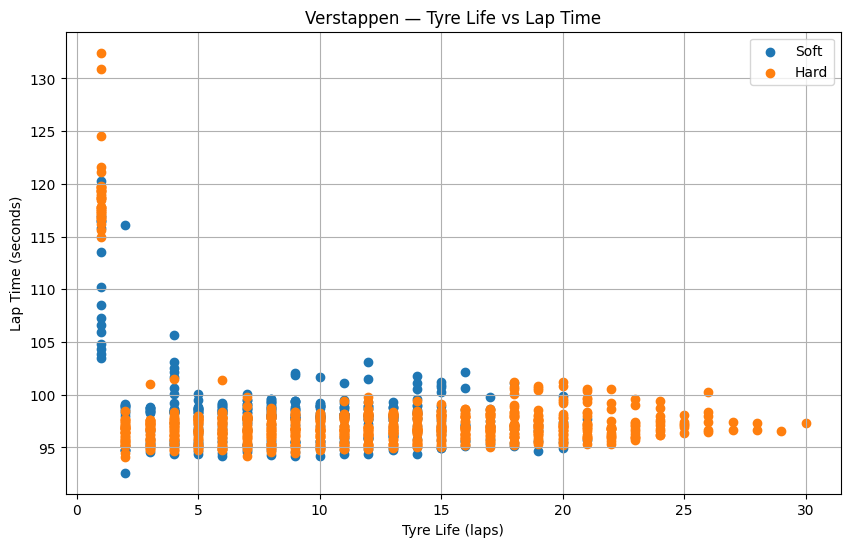

In [47]:


# Convert LapTime into seconds for analysis
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()

# Separate the compounds
soft = laps[laps["Compound"] == "SOFT"]
hard = laps[laps["Compound"] == "HARD"]

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    soft["TyreLife"],
    soft["LapTimeSeconds"],
    label="Soft"
)

plt.scatter(
    hard["TyreLife"],
    hard["LapTimeSeconds"],
    label="Hard"
)

# Labels
plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Verstappen — Tyre Life vs Lap Time")

plt.legend()
plt.grid(True)

plt.show()

In [48]:
# so i jst need to check which tyre has perform the best for that ill need -> stint, Compound,  TyreLife, LapTime

In [49]:
ver_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [50]:
ver_laps[['Compound','Stint','TyreLife','LapTimeSeconds']]

,Compound,Stint,TyreLife,LapTimeSeconds
0,SOFT,1.0,4.0,97.284
1,SOFT,1.0,5.0,96.296
2,SOFT,1.0,6.0,96.753
3,SOFT,1.0,7.0,96.647
4,SOFT,1.0,8.0,97.173
5,SOFT,1.0,9.0,97.092
6,SOFT,1.0,10.0,97.038
7,SOFT,1.0,11.0,97.024
8,SOFT,1.0,12.0,97.229
9,SOFT,1.0,13.0,96.960


In [51]:
ver_laps.groupby('Compound')['LapTimeSeconds'].describe()

,count,mean,std,min,25%,50%,75%,max
Compound,,,,,,,,
HARD,20.0,96.876350,5.015311,95.160,95.2875,95.630,95.919,117.854
SOFT,37.0,96.411216,3.680227,92.608,94.6670,96.296,97.038,116.445


In [52]:
ver_laps.groupby('Stint')[['LapTimeSeconds','Compound']].describe()


LapTimeSeconds                                                          \
               count       mean       std     min       25%     50%      75%   
Stint                                                                          
1.0             17.0  97.162294  0.743079  96.296  97.01100  97.038  97.1680   
2.0             20.0  96.876350  5.015311  95.160  95.28750  95.630  95.9190   
3.0             20.0  95.772800  4.925820  92.608  94.31725  94.669  95.2105   

                
           max  
Stint           
1.0     99.896  
2.0    117.854  
3.0    116.445

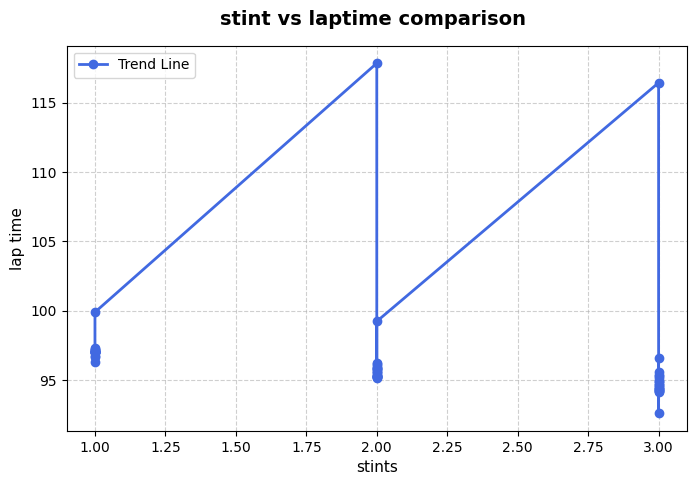

In [53]:
import matplotlib.pyplot as plt

# 1. Define the data points
x = ver_laps['Stint']
y = ver_laps['LapTimeSeconds']

# 2. Initialize the figure size (optional but recommended)
plt.figure(figsize=(8, 5))

# 3. Create the line plot with styling
plt.plot(x, y, 
         color='royalblue',     # Line color
         linestyle='-',         # Solid line ('--', ':', or '-.' also work)
         linewidth=2,           # Line thickness
         marker='o',            # Data point marker shape
         markersize=6,          # Size of markers
         label='Trend Line')    # Label for the legend

# 4. Add titles and axis labels
plt.title('stint vs laptime comparison ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('stints', fontsize=11)
plt.ylabel('lap time', fontsize=11)

# 5. Add a grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# 6. Display the graph
plt.show()


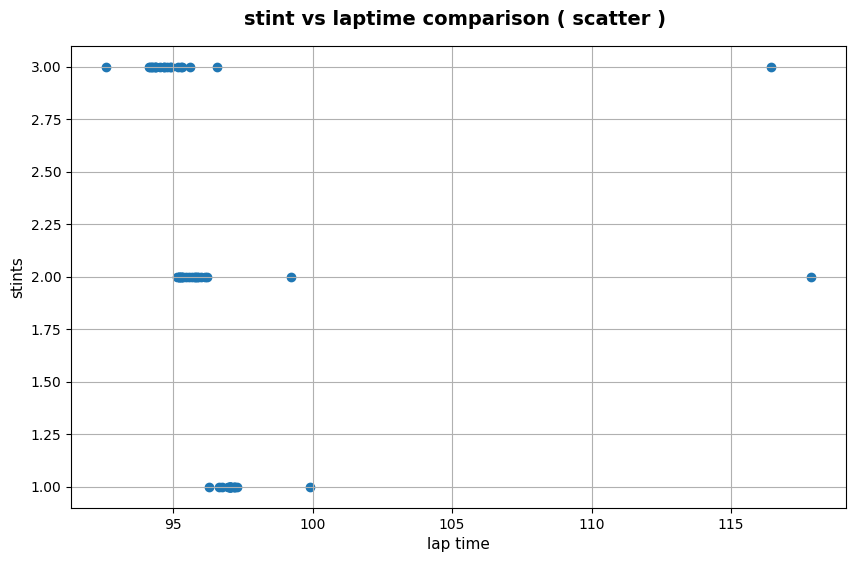

In [54]:


y= ver_laps['Stint']
x = ver_laps['LapTimeSeconds']

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    
)



# Labels
plt.title('stint vs laptime comparison ( scatter ) ', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('stints', fontsize=11)
plt.xlabel('lap time', fontsize=11)


plt.grid(True)

plt.show()

In [55]:
# we can conclude this that the lap time was increasing gradually as per the tyre life was increasing . 
# and the new set of tyre are faster that too gradually 



In [56]:
# now well compare tyre life with the lap time 

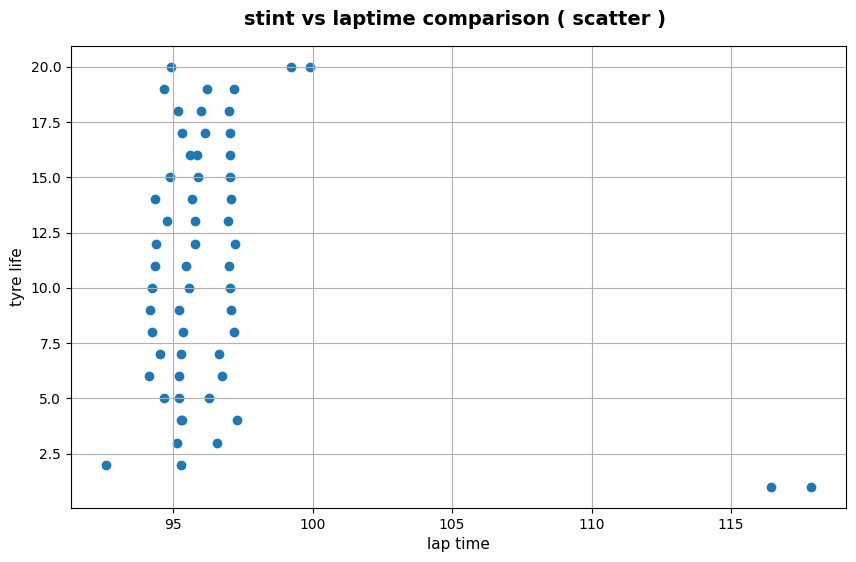

In [57]:
x = ver_laps['LapTimeSeconds']
y = ver_laps['TyreLife']

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    
    x,
    y,
    
)



# Labels
plt.title('stint vs laptime comparison ( scatter ) ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('lap time', fontsize=11)
plt.ylabel('tyre life', fontsize=11)


plt.grid(True)

plt.show()

In [58]:
# so now there is a bit of a change in the strategy and now we have a new road map and blur print planned and now we are going to work accordingly 
# so now the new idea is we have created a tree and every check points are deciced so we have to complete it accordinly.

In [59]:
# so we are in the C. data investigation and eda. 
#     and in that we are working on the C3.race progression.


In [60]:
# # race progression - How does a driver's performance and race state evolve as the race progresses from Lap 1 → final lap?
# need to observe : -
# Lap time progression
# Position progression
# Tyre/compound progression
# Tyre life progression
# Stint changes
# Pit stops
# Track-status changes

In [61]:
laps.columns


Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

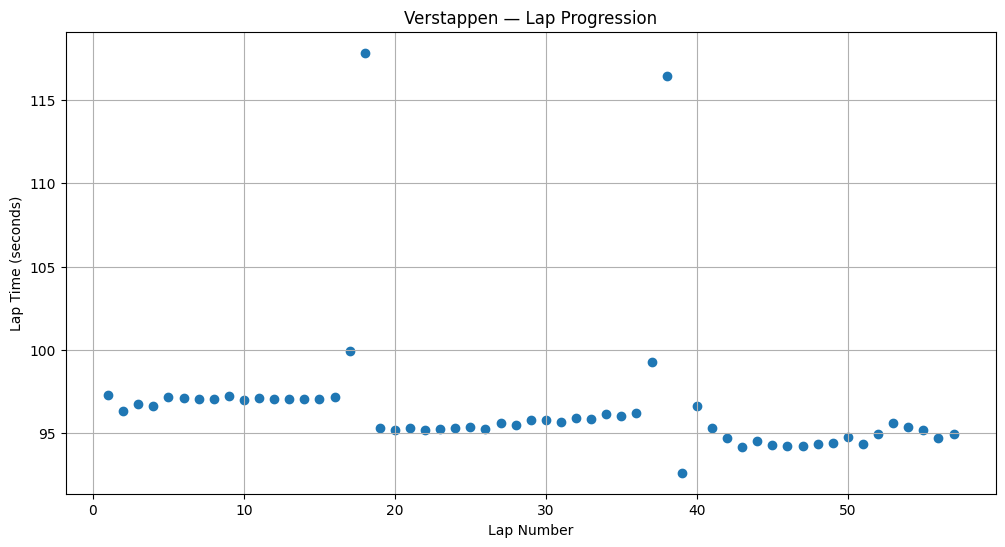

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(
    ver_laps["LapNumber"],
    ver_laps["LapTimeSeconds"]
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Verstappen — Lap Progression")

plt.grid(True)
plt.show()

In [63]:
# What the graph actually tells us

# 1. Lap times are fairly stable within each stint.
# Correct. Most laps sit in a relatively narrow band rather than continuously getting slower.

# 2. There are clear discontinuities around the pit stops.
# Correct. The ~118 s and ~116 s laps are obvious abnormal laps, and the ~100 s laps are also suspicious. These shouldn't be treated as normal racing pace.

# 3. The second/third tyre stint appears faster.
# You can observe that the later laps are generally around 94–95.5 s, compared with roughly 95–97 s earlier.

# althought we can jump on the direcrt conclusion that the new set of tyre are always better cause over the span of race , many other variable changes
# such as fuel , weather and track condition etc 


In [64]:
# C3.2 - lap number vs pos

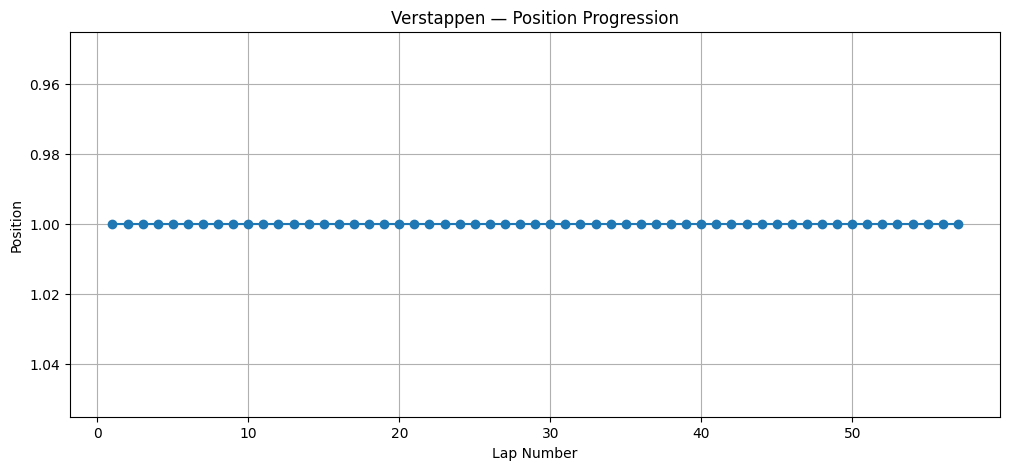

In [65]:
plt.figure(figsize=(12, 5))

plt.plot(
    ver_laps["LapNumber"],
    ver_laps["Position"],
    marker="o"
)

plt.gca().invert_yaxis()

plt.xlabel("Lap Number")
plt.ylabel("Position")
plt.title("Verstappen — Position Progression")

plt.grid(True)
plt.show()

In [66]:
# C3.3 - PACE EVALUTAION THROUGH OUT  THE RACE 

# How did Verstappen's pace change throughout the race, and how did that pace behave within each stint?


In [67]:
ver_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [68]:
ver_pace_data = ver_laps[
    (ver_laps["LapTimeSeconds"].notna()) &
    (ver_laps["PitInTime"].isna()) &
    (ver_laps["PitOutTime"].isna())
].copy()

# we have removed all the out lier and everythig from it so we can work in the clean data . to understand the speend and lap stint . 

ver_pace_data

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
0,0 days 01:01:37.489000,VER,1,0 days 00:01:37.284000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.266000,...,Red Bull Racing,0 days 00:59:59.911000,2024-03-02 15:03:42.342,12,1.0,False,,False,False,97.284
1,0 days 01:03:13.785000,VER,1,0 days 00:01:36.296000,2.0,1.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:41.661000,...,Red Bull Racing,0 days 01:01:37.489000,2024-03-02 15:05:19.920,1,1.0,False,,False,True,96.296
2,0 days 01:04:50.538000,VER,1,0 days 00:01:36.753000,3.0,1.0,NaT,NaT,0 days 00:00:30.999000,0 days 00:00:41.966000,...,Red Bull Racing,0 days 01:03:13.785000,2024-03-02 15:06:56.216,1,1.0,False,,False,True,96.753
3,0 days 01:06:27.185000,VER,1,0 days 00:01:36.647000,4.0,1.0,NaT,NaT,0 days 00:00:30.931000,0 days 00:00:41.892000,...,Red Bull Racing,0 days 01:04:50.538000,2024-03-02 15:08:32.969,1,1.0,False,,False,True,96.647
4,0 days 01:08:04.358000,VER,1,0 days 00:01:37.173000,5.0,1.0,NaT,NaT,0 days 00:00:31.255000,0 days 00:00:42.056000,...,Red Bull Racing,0 days 01:06:27.185000,2024-03-02 15:10:09.616,1,1.0,False,,False,True,97.173
5,0 days 01:09:41.450000,VER,1,0 days 00:01:37.092000,6.0,1.0,NaT,NaT,0 days 00:00:31.041000,0 days 00:00:42.187000,...,Red Bull Racing,0 days 01:08:04.358000,2024-03-02 15:11:46.789,1,1.0,False,,False,True,97.092
6,0 days 01:11:18.488000,VER,1,0 days 00:01:37.038000,7.0,1.0,NaT,NaT,0 days 00:00:31.015000,0 days 00:00:42.118000,...,Red Bull Racing,0 days 01:09:41.450000,2024-03-02 15:13:23.881,1,1.0,False,,False,True,97.038
7,0 days 01:12:55.512000,VER,1,0 days 00:01:37.024000,8.0,1.0,NaT,NaT,0 days 00:00:31.041000,0 days 00:00:42.077000,...,Red Bull Racing,0 days 01:11:18.488000,2024-03-02 15:15:00.919,1,1.0,False,,False,True,97.024
8,0 days 01:14:32.741000,VER,1,0 days 00:01:37.229000,9.0,1.0,NaT,NaT,0 days 00:00:31.100000,0 days 00:00:42.166000,...,Red Bull Racing,0 days 01:12:55.512000,2024-03-02 15:16:37.943,1,1.0,False,,False,True,97.229
9,0 days 01:16:09.701000,VER,1,0 days 00:01:36.960000,10.0,1.0,NaT,NaT,0 days 00:00:30.986000,0 days 00:00:42.009000,...,Red Bull Racing,0 days 01:14:32.741000,2024-03-02 15:18:15.172,12,1.0,False,,False,True,96.960


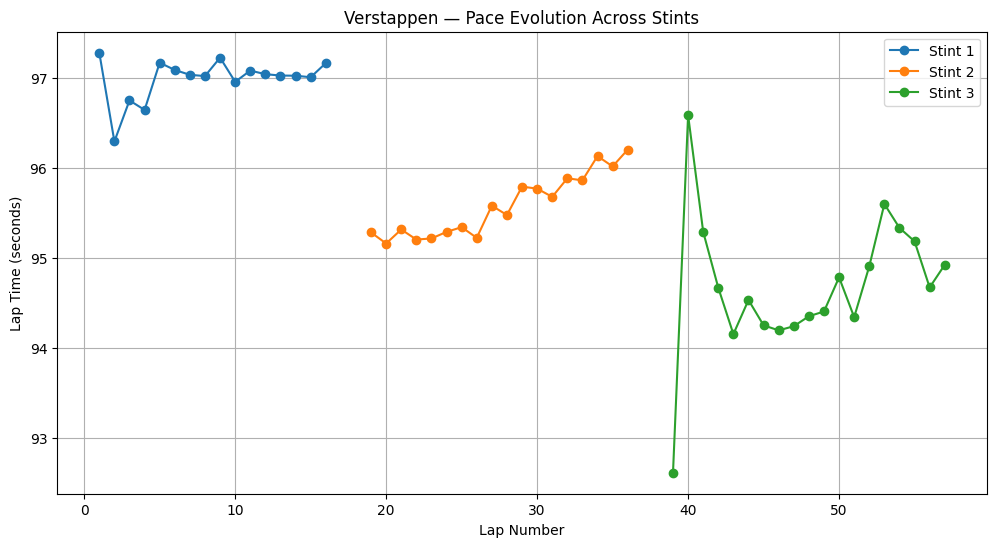

In [69]:

plt.figure(figsize=(12, 6))

for stint, data in ver_pace_data.groupby("Stint"):

    plt.plot(
        data["LapNumber"],
        data["LapTimeSeconds"],
        marker="o",
        label=f"Stint {int(stint)}"
    )

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Verstappen — Pace Evolution Across Stints")

plt.legend()
plt.grid(True)

plt.show()

# my doubt is data is a new data frame ? , na if that so then it has group by of stint from the ver_pace_Data ? so we have crearted an new data frame 

In [70]:
# NOW WE ARE STARTING OUT WITH THE C4 WHICH IS POSITION AND TRAFFIC .


# goal for the c4 is to understand how does this traffic affect the lap time and position.
#  how much it affect the lap time overall 


In [71]:
laps.columns


Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [72]:
position_change = (
    laps.groupby('Driver')['Position']
    .agg(["min", "max", "nunique"])
    .sort_values("nunique", ascending=False)
)

position_change

,min,max,nunique
Driver,,,
STR,9.0,19.0,11
ALB,5.0,16.0,10
ALO,2.0,11.0,10
HUL,12.0,20.0,9
TSU,4.0,15.0,9
ZHO,9.0,17.0,9
RUS,2.0,11.0,8
LEC,2.0,13.0,8
RIC,10.0,16.0,7


In [73]:
# so now we want to understand the traffic and positions affect the lap time so we are working on 
# it  and for that we need a diffrent contendor to understand the whole data set accordingly .
#  because verstapan started on p1 ended on p1 

# so we are selecting zou for this 

In [74]:
zhou_laps = laps[laps["Driver"] == "ZHO"].copy()

In [75]:
zhou_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [76]:
zhou_laps[['LapNumber','Stint','Position','TyreLife','Compound','TrackStatus']]

,LapNumber,Stint,Position,TyreLife,Compound,TrackStatus
570,1.0,1.0,13.0,1.0,SOFT,12
571,2.0,1.0,13.0,2.0,SOFT,1
572,3.0,1.0,13.0,3.0,SOFT,1
573,4.0,1.0,13.0,4.0,SOFT,1
574,5.0,1.0,13.0,5.0,SOFT,1
575,6.0,1.0,13.0,6.0,SOFT,1
576,7.0,1.0,13.0,7.0,SOFT,1
577,8.0,1.0,13.0,8.0,SOFT,1
578,9.0,1.0,16.0,9.0,SOFT,1
579,10.0,2.0,17.0,1.0,HARD,12


In [77]:

zhou_laps[['LapNumber','Stint','Position','TyreLife','Compound','TrackStatus']].describe()

,LapNumber,Stint,Position,TyreLife
count,56.000000,56.000000,56.000000,56.000000
mean,28.500000,2.339286,11.910714,11.446429
std,16.309506,0.745332,2.011574,7.546028
min,1.000000,1.000000,9.000000,1.000000
25%,14.750000,2.000000,10.750000,5.000000
50%,28.500000,2.500000,11.000000,10.000000
75%,42.250000,3.000000,13.000000,17.000000
max,56.000000,3.000000,17.000000,28.000000


In [78]:
zhou_laps[['LapNumber', 'Position']].assign(Pos_Change=zhou_laps['Position'].diff())

,LapNumber,Position,Pos_Change
570,1.0,13.0,NaN
571,2.0,13.0,0.0
572,3.0,13.0,0.0
573,4.0,13.0,0.0
574,5.0,13.0,0.0
575,6.0,13.0,0.0
576,7.0,13.0,0.0
577,8.0,13.0,0.0
578,9.0,16.0,3.0
579,10.0,17.0,1.0


In [79]:
# so we are studying about the posistion changes of the driver so as per i am noticing , the position change happend becauuse of pit stops


In [80]:
zhou_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds'],
      dtype='object')

In [81]:
laps.groupby('Driver')[['Stint','LapNumber']].describe()

Stint                                               LapNumber        \
       count      mean       std  min   25%  50%  75%  max     count  mean   
Driver                                                                       
ALB     56.0  2.089286  0.792620  1.0  1.00  2.0  3.0  3.0      56.0  28.5   
ALO     57.0  2.017544  0.743813  1.0  1.00  2.0  3.0  3.0      57.0  29.0   
BOT     56.0  2.250000  0.792006  1.0  2.00  2.0  3.0  3.0      56.0  28.5   
GAS     56.0  2.464286  1.078118  1.0  2.00  2.0  3.0  4.0      56.0  28.5   
HAM     57.0  2.210526  0.773139  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
HUL     56.0  2.892857  0.824149  1.0  2.00  3.0  4.0  4.0      56.0  28.5   
LEC     57.0  2.210526  0.749687  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
MAG     56.0  2.232143  0.762557  1.0  2.00  2.0  3.0  3.0      56.0  28.5   
NOR     57.0  2.192982  0.789181  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
OCO     56.0  2.285714  0.755929  1.0  2.00  2.0  3.0  3.0      56.0  28.5   
PER     57.0  2.157895  0.750939  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
PIA     57.0  2.192982  0.766220  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
RIC     56.0  2.142857  0.772918  1.0  2.00  2.0  3.0  3.0      56.0  28.5   
RUS     57.0  2.263158  0.768261  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
SAI     57.0  2.140351  0.789181  1.0  2.00  2.0  3.0  3.0      57.0  29.0   
SAR     55.0  2.581818  1.083392  1.0  2.00  2.0  4.0  4.0      55.0  28.0   
STR     57.0  2.368421  0.747175  1.0  2.00  3.0  3.0  3.0      57.0  29.0   
TSU     56.0  2.142857  0.796094  1.0  1.75  2.0  3.0  3.0      56.0  28.5   
VER     57.0  2.052632  0.811107  1.0  1.00  2.0  3.0  3.0      57.0  29.0   
ZHO     56.0  2.339286  0.745332  1.0  2.00  2.5  3.0  3.0      56.0  28.5   

                                                  
              std  min    25%   50%    75%   max  
Driver                                            
ALB     16.309506  1.0  14.75  28.5  42.25  56.0  
ALO     16.598193  1.0  15.00  29.0  43.00  57.0  
BOT     16.309506  1.0  14.75  28.5  42.25  56.0  
GAS     16.309506  1.0  14.75  28.5  42.25  56.0  
HAM     16.598193  1.0  15.00  29.0  43.00  57.0  
HUL     16.309506  1.0  14.75  28.5  42.25  56.0  
LEC     16.598193  1.0  15.00  29.0  43.00  57.0  
MAG     16.309506  1.0  14.75  28.5  42.25  56.0  
NOR     16.598193  1.0  15.00  29.0  43.00  57.0  
OCO     16.309506  1.0  14.75  28.5  42.25  56.0  
PER     16.598193  1.0  15.00  29.0  43.00  57.0  
PIA     16.598193  1.0  15.00  29.0  43.00  57.0  
RIC     16.309506  1.0  14.75  28.5  42.25  56.0  
RUS     16.598193  1.0  15.00  29.0  43.00  57.0  
SAI     16.598193  1.0  15.00  29.0  43.00  57.0  
SAR     16.020820  1.0  14.50  28.0  41.50  55.0  
STR     16.598193  1.0  15.00  29.0  43.00  57.0  
TSU     16.309506  1.0  14.75  28.5  42.25  56.0  
VER     16.598193  1.0  15.00  29.0  43.00  57.0  
ZHO     16.309506  1.0  14.75  28.5  42.25  56.0

In [82]:
stint_summary = laps.groupby(['Driver', 'Stint'])['LapNumber'].min().reset_index()

print(stint_summary[stint_summary['Driver'] == 'ALB'])
print(stint_summary[stint_summary['Driver'] == 'ZHO'])
print(stint_summary[stint_summary['Driver'] == 'SAR'])
print(stint_summary[stint_summary['Driver'] == 'OCO'])

# yes so in middle order every one pitted around the same lap time . and the over take happened 
# happened because of it .

  Driver  Stint  LapNumber
0    ALB    1.0        1.0
1    ALB    2.0       16.0
2    ALB    3.0       37.0
   Driver  Stint  LapNumber
60    ZHO    1.0        1.0
61    ZHO    2.0       10.0
62    ZHO    3.0       29.0
   Driver  Stint  LapNumber
47    SAR    1.0        1.0
48    SAR    2.0       11.0
49    SAR    3.0       29.0
50    SAR    4.0       41.0
   Driver  Stint  LapNumber
29    OCO    1.0        1.0
30    OCO    2.0       11.0
31    OCO    3.0       31.0


In [83]:
stint_lengths = laps.groupby(['Driver', 'Stint']).size().reset_index(name='Laps in Stint')

print(stint_lengths[stint_lengths['Driver'] == 'ALB'])
print(stint_lengths[stint_lengths['Driver'] == 'ZHO'])
print(stint_lengths[stint_lengths['Driver'] == 'SAR'])
print(stint_lengths[stint_lengths['Driver'] == 'OCO'])

# yes the lap numbers are also similar the zhou has potentially over taken due to pit stop conditions.

  Driver  Stint  Laps in Stint
0    ALB    1.0             15
1    ALB    2.0             21
2    ALB    3.0             20
   Driver  Stint  Laps in Stint
60    ZHO    1.0              9
61    ZHO    2.0             19
62    ZHO    3.0             28
   Driver  Stint  Laps in Stint
47    SAR    1.0             10
48    SAR    2.0             18
49    SAR    3.0             12
50    SAR    4.0             15
   Driver  Stint  Laps in Stint
29    OCO    1.0             10
30    OCO    2.0             20
31    OCO    3.0             26


In [84]:
zhou_laps["PositionChange"] = zhou_laps["Position"].diff()

position_events = zhou_laps[
    zhou_laps["PositionChange"].notna() &
    (zhou_laps["PositionChange"] != 0)
][
    [
        "LapNumber",
        "Position",
        "PositionChange",
        "LapTimeSeconds",
        "Compound",
        "TyreLife",
        "Stint",
        "PitInTime",
        "PitOutTime"
    ]
]

position_events

,LapNumber,Position,PositionChange,LapTimeSeconds,Compound,TyreLife,Stint,PitInTime,PitOutTime
578,9.0,16.0,3.0,101.849,SOFT,9.0,1.0,0 days 01:14:57.559000,NaT
579,10.0,17.0,1.0,119.328,HARD,1.0,2.0,NaT,0 days 01:15:22.700000
580,11.0,16.0,-1.0,96.365,HARD,2.0,2.0,NaT,NaT
581,12.0,15.0,-1.0,96.995,HARD,3.0,2.0,NaT,NaT
582,13.0,13.0,-2.0,97.436,HARD,4.0,2.0,NaT,NaT
583,14.0,12.0,-1.0,97.482,HARD,5.0,2.0,NaT,NaT
584,15.0,11.0,-1.0,97.500,HARD,6.0,2.0,NaT,NaT
585,16.0,9.0,-2.0,97.659,HARD,7.0,2.0,NaT,NaT
586,17.0,10.0,1.0,98.475,HARD,8.0,2.0,NaT,NaT
597,28.0,11.0,1.0,100.675,HARD,19.0,2.0,0 days 01:46:17.855000,NaT


In [85]:
# Position changes in this race cannot simply be treated as overtakes.
# Some occur during pit-stop cycles, while others occur during normal racing.

In [86]:
zhou_laps["PitLap"] = (
    zhou_laps["PitInTime"].notna() |
    zhou_laps["PitOutTime"].notna()
)


zhou_laps

zhou_position_events = zhou_laps[
    zhou_laps["PositionChange"].notna() &
    (zhou_laps["PositionChange"] != 0)
][
    [
        "LapNumber",
        "Position",
        "PositionChange",
        "LapTimeSeconds",
        "Compound",
        "TyreLife",
        "Stint",
        "PitLap"
    ]
]

zhou_position_events




,LapNumber,Position,PositionChange,LapTimeSeconds,Compound,TyreLife,Stint,PitLap
578,9.0,16.0,3.0,101.849,SOFT,9.0,1.0,True
579,10.0,17.0,1.0,119.328,HARD,1.0,2.0,True
580,11.0,16.0,-1.0,96.365,HARD,2.0,2.0,False
581,12.0,15.0,-1.0,96.995,HARD,3.0,2.0,False
582,13.0,13.0,-2.0,97.436,HARD,4.0,2.0,False
583,14.0,12.0,-1.0,97.482,HARD,5.0,2.0,False
584,15.0,11.0,-1.0,97.500,HARD,6.0,2.0,False
585,16.0,9.0,-2.0,97.659,HARD,7.0,2.0,False
586,17.0,10.0,1.0,98.475,HARD,8.0,2.0,False
597,28.0,11.0,1.0,100.675,HARD,19.0,2.0,True


In [87]:
zhou_position_events[zhou_position_events['PitLap'] == True]

,LapNumber,Position,PositionChange,LapTimeSeconds,Compound,TyreLife,Stint,PitLap
578,9.0,16.0,3.0,101.849,SOFT,9.0,1.0,True
579,10.0,17.0,1.0,119.328,HARD,1.0,2.0,True
597,28.0,11.0,1.0,100.675,HARD,19.0,2.0,True
598,29.0,17.0,6.0,117.076,HARD,1.0,3.0,True


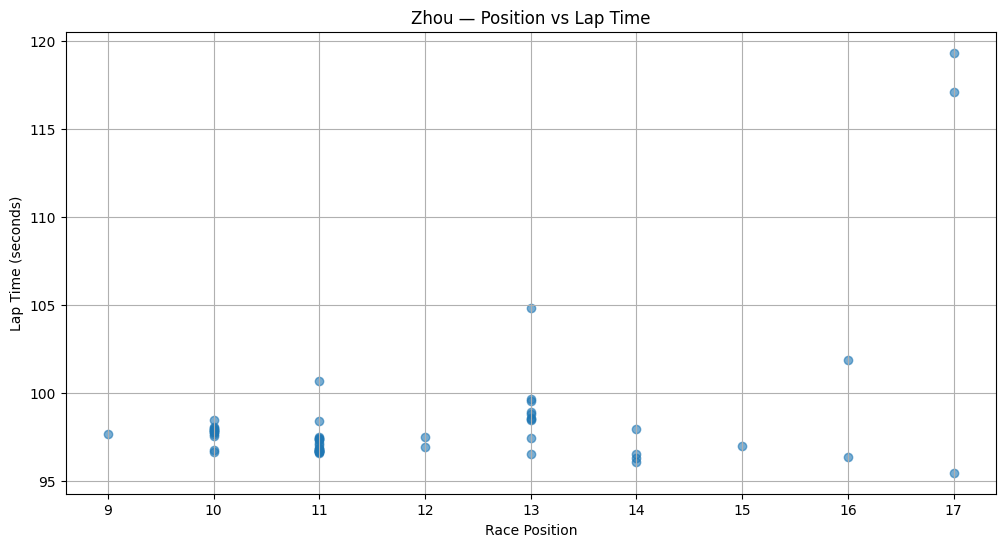

In [88]:
plt.figure(figsize=(12, 6))

plt.scatter(
    zhou_laps["Position"],
    zhou_laps["LapTimeSeconds"],
    alpha=0.6
)

plt.xlabel("Race Position")
plt.ylabel("Lap Time (seconds)")
plt.title("Zhou — Position vs Lap Time")
plt.grid(True)

plt.show()

In [89]:
# ---------------------------------- C4.2 TRAFFIC VS LAP TIME ---------------------------



In [90]:
laps.columns.tolist()

['Time',
 'Driver',
 'DriverNumber',
 'LapTime',
 'LapNumber',
 'Stint',
 'PitOutTime',
 'PitInTime',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'Sector1SessionTime',
 'Sector2SessionTime',
 'Sector3SessionTime',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'IsPersonalBest',
 'Compound',
 'TyreLife',
 'FreshTyre',
 'Team',
 'LapStartTime',
 'LapStartDate',
 'TrackStatus',
 'Position',
 'Deleted',
 'DeletedReason',
 'FastF1Generated',
 'IsAccurate',
 'LapTimeSeconds']

In [91]:
[col for col in laps.columns if any(
    word in col.lower()
    for word in ["gap", "interval", "position"]
)]

['Position']

In [92]:
%whos


Variable               Type         Data/Info
---------------------------------------------
average_laptime        Series       Shape: (2,)
data                   Laps                              Time<...>n\n[19 rows x 32 columns]
f1_data                Session      2024 Season Round 1: Bahrain Grand Prix - Race
f1_data_british        Session      2026 Season Round 9: British Grand Prix - Race
fastf1                 module       <module 'fastf1' from 'c:<...>es\\fastf1\\__init__.py'>
hard                   Laps                                Ti<...>\n[791 rows x 32 columns]
laps                   Laps                                Ti<...>n[1129 rows x 32 columns]
laps_british           Laps                                Ti<...>n[1113 rows x 31 columns]
np                     module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd                     module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt                    module       <module 'matpl

In [93]:
dir(f1_data)

['_QUALI_LIKE_SESSIONS',
 '_RACE_LIKE_SESSIONS',
 '_Session__fix_tyre_info',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_first_lap_time_from_ergast',
 '_add_track_status_to_laps',
 '_calculate_quali_like_session_results',
 '_calculate_race_like_session_results',
 '_calculate_t0_date',
 '_car_data',
 '_check_lap_accuracy',
 '_drivers_from_f1_api',
 '_drivers_results_from_ergast',
 '_ergast',
 '_fix_missing_laps_retired_on_track',
 '_get_property_warn_not_loaded',
 '_laps',
 '_load_drivers_results',
 '_load_laps_data',
 '_load_race_control_messages',
 '_load_session_info',
 '_load_session_status_dat

In [94]:
f1_data.pos_data

{'1':                          Date   Status      X       Y      Z Source  \
 0     2024-03-02 14:03:43.899  OnTrack    0.0     0.0    0.0    pos   
 1     2024-03-02 14:03:44.219  OnTrack    0.0     0.0    0.0    pos   
 2     2024-03-02 14:03:44.460  OnTrack    0.0     0.0    0.0    pos   
 3     2024-03-02 14:03:44.720  OnTrack    0.0     0.0    0.0    pos   
 4     2024-03-02 14:03:45.000  OnTrack    0.0     0.0    0.0    pos   
 ...                       ...      ...    ...     ...    ...    ...   
 35989 2024-03-02 16:39:15.699  OnTrack -219.0  1465.0 -159.0    pos   
 35990 2024-03-02 16:39:15.859  OnTrack -219.0  1465.0 -159.0    pos   
 35991 2024-03-02 16:39:15.979  OnTrack -219.0  1465.0 -159.0    pos   
 35992 2024-03-02 16:39:16.179  OnTrack -219.0  1465.0 -159.0    pos   
 35993 2024-03-02 16:39:16.379  OnTrack -219.0  1465.0 -159.0    pos   
 
                         Time            SessionTime  
 0     0 days 00:00:01.468000 0 days 00:00:01.468000  
 1     0 days 00:00

In [95]:
f1_data.pos_data.keys()

zhou_pos = f1_data.pos_data['24']

In [96]:
zhou_pos

,Date,Status,X,Y,Z,Source,Time,SessionTime
0,2024-03-02 14:03:43.899,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:01.468000,0 days 00:00:01.468000
1,2024-03-02 14:03:44.219,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:01.788000,0 days 00:00:01.788000
2,2024-03-02 14:03:44.460,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.029000,0 days 00:00:02.029000
3,2024-03-02 14:03:44.720,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.289000,0 days 00:00:02.289000
4,2024-03-02 14:03:45.000,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.569000,0 days 00:00:02.569000
...,...,...,...,...,...,...,...,...
35989,2024-03-02 16:39:15.699,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.268000,0 days 02:35:33.268000
35990,2024-03-02 16:39:15.859,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.428000,0 days 02:35:33.428000
35991,2024-03-02 16:39:15.979,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.548000,0 days 02:35:33.548000
35992,2024-03-02 16:39:16.179,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.748000,0 days 02:35:33.748000


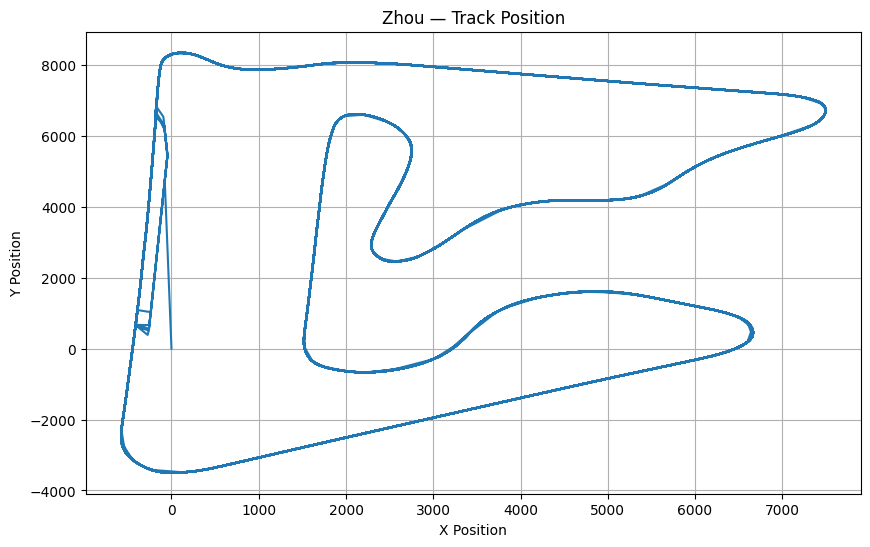

In [97]:
plt.figure(figsize=(10, 6))

plt.plot(
    zhou_pos["X"],
    zhou_pos["Y"]
)

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Zhou — Track Position")
plt.grid(True)

plt.show()

In [98]:
f1_data.pos_data.keys()

dict_keys(['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2'])

In [99]:
# testing the data with ocon

ocon_pos = f1_data.pos_data["31"]

ocon_pos.head()

,Date,Status,X,Y,Z,Source,Time,SessionTime
0,2024-03-02 14:03:43.899,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:01.468000,0 days 00:00:01.468000
1,2024-03-02 14:03:44.219,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:01.788000,0 days 00:00:01.788000
2,2024-03-02 14:03:44.460,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.029000,0 days 00:00:02.029000
3,2024-03-02 14:03:44.720,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.289000,0 days 00:00:02.289000
4,2024-03-02 14:03:45.000,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.569000,0 days 00:00:02.569000


In [100]:
len(zhou_pos), len(ocon_pos)

(35994, 35994)

In [101]:
# we are now calculating the pos btw the 2 driver.

In [102]:
distance = (
    (zhou_pos['X'] - ocon_pos['X'] )**2
    + (zhou_pos["Y"] - ocon_pos["Y"])**2
    + (zhou_pos["Z"] - ocon_pos["Z"])**2
)**0.5

In [103]:
distance.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
dtype: float64

In [104]:
zhou_pos[(zhou_pos["X"] != 0) | (zhou_pos["Y"] != 0) | (zhou_pos["Z"] != 0)]

,Date,Status,X,Y,Z,Source,Time,SessionTime
3779,2024-03-02 14:20:03.859,OnTrack,-77.0,4744.0,0.0,pos,0 days 00:16:21.428000,0 days 00:16:21.428000
3780,2024-03-02 14:20:04.319,OnTrack,-76.0,4773.0,0.0,pos,0 days 00:16:21.888000,0 days 00:16:21.888000
3781,2024-03-02 14:20:04.780,OnTrack,-74.0,4802.0,0.0,pos,0 days 00:16:22.349000,0 days 00:16:22.349000
3782,2024-03-02 14:20:04.860,OnTrack,-74.0,4807.0,0.0,pos,0 days 00:16:22.429000,0 days 00:16:22.429000
3783,2024-03-02 14:20:05.040,OnTrack,-74.0,4820.0,0.0,pos,0 days 00:16:22.609000,0 days 00:16:22.609000
...,...,...,...,...,...,...,...,...
35989,2024-03-02 16:39:15.699,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.268000,0 days 02:35:33.268000
35990,2024-03-02 16:39:15.859,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.428000,0 days 02:35:33.428000
35991,2024-03-02 16:39:15.979,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.548000,0 days 02:35:33.548000
35992,2024-03-02 16:39:16.179,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.748000,0 days 02:35:33.748000


In [105]:
zhou_pos["Time"].equals(ocon_pos["Time"])


True

In [106]:
zhou_valid = zhou_pos[
    (zhou_pos["X"] != 0) |
    (zhou_pos["Y"] != 0) |
    (zhou_pos["Z"] != 0)
].copy()

ocon_valid = ocon_pos[
    (ocon_pos["X"] != 0) |
    (ocon_pos["Y"] != 0) |
    (ocon_pos["Z"] != 0)
].copy()

In [107]:
zhou_valid["Time"].equals(ocon_valid["Time"])

False

In [108]:
distance = (
    (zhou_pos["X"] - ocon_pos["X"])**2
    + (zhou_pos["Y"] - ocon_pos["Y"])**2
    + (zhou_pos["Z"] - ocon_pos["Z"])**2
)**0.5

distance

0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
           ...    
35989    79.101201
35990    79.101201
35991    79.101201
35992    79.101201
35993    79.101201
Length: 35994, dtype: float64

In [109]:
zhou_valid.merge(ocon_valid, on="Time")

,Date_x,Status_x,X_x,Y_x,Z_x,Source_x,Time,SessionTime_x,Date_y,Status_y,X_y,Y_y,Z_y,Source_y,SessionTime_y
0,2024-03-02 14:20:45.940,OnTrack,7481.0,6845.0,7.0,pos,0 days 00:17:03.509000,0 days 00:17:03.509000,2024-03-02 14:20:45.940,OnTrack,-127.0,3607.0,0.0,pos,0 days 00:17:03.509000
1,2024-03-02 14:20:46.220,OnTrack,7495.0,6768.0,8.0,pos,0 days 00:17:03.789000,0 days 00:17:03.789000,2024-03-02 14:20:46.220,OnTrack,-119.0,3768.0,0.0,pos,0 days 00:17:03.789000
2,2024-03-02 14:20:46.240,OnTrack,7495.0,6762.0,8.0,pos,0 days 00:17:03.809000,0 days 00:17:03.809000,2024-03-02 14:20:46.240,OnTrack,-119.0,3773.0,0.0,pos,0 days 00:17:03.809000
3,2024-03-02 14:20:46.520,OnTrack,7495.0,6681.0,8.0,pos,0 days 00:17:04.089000,0 days 00:17:04.089000,2024-03-02 14:20:46.520,OnTrack,-116.0,3832.0,0.0,pos,0 days 00:17:04.089000
4,2024-03-02 14:20:46.840,OnTrack,7483.0,6589.0,8.0,pos,0 days 00:17:04.409000,0 days 00:17:04.409000,2024-03-02 14:20:46.840,OnTrack,-114.0,3895.0,0.0,pos,0 days 00:17:04.409000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32047,2024-03-02 16:39:15.699,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.268000,0 days 02:35:33.268000,2024-03-02 16:39:15.699,OnTrack,-250.0,765.0,-159.0,pos,0 days 02:35:33.268000
32048,2024-03-02 16:39:15.859,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.428000,0 days 02:35:33.428000,2024-03-02 16:39:15.859,OnTrack,-250.0,765.0,-159.0,pos,0 days 02:35:33.428000
32049,2024-03-02 16:39:15.979,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.548000,0 days 02:35:33.548000,2024-03-02 16:39:15.979,OnTrack,-250.0,765.0,-159.0,pos,0 days 02:35:33.548000
32050,2024-03-02 16:39:16.179,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.748000,0 days 02:35:33.748000,2024-03-02 16:39:16.179,OnTrack,-250.0,765.0,-159.0,pos,0 days 02:35:33.748000


In [110]:
comparison = zhou_valid.merge(
    ocon_valid,
    on="Time",
    suffixes=("_zhou", "_ocon")
)

comparison.head()

,Date_zhou,Status_zhou,X_zhou,Y_zhou,Z_zhou,Source_zhou,Time,SessionTime_zhou,Date_ocon,Status_ocon,X_ocon,Y_ocon,Z_ocon,Source_ocon,SessionTime_ocon
0,2024-03-02 14:20:45.940,OnTrack,7481.0,6845.0,7.0,pos,0 days 00:17:03.509000,0 days 00:17:03.509000,2024-03-02 14:20:45.940,OnTrack,-127.0,3607.0,0.0,pos,0 days 00:17:03.509000
1,2024-03-02 14:20:46.220,OnTrack,7495.0,6768.0,8.0,pos,0 days 00:17:03.789000,0 days 00:17:03.789000,2024-03-02 14:20:46.220,OnTrack,-119.0,3768.0,0.0,pos,0 days 00:17:03.789000
2,2024-03-02 14:20:46.240,OnTrack,7495.0,6762.0,8.0,pos,0 days 00:17:03.809000,0 days 00:17:03.809000,2024-03-02 14:20:46.240,OnTrack,-119.0,3773.0,0.0,pos,0 days 00:17:03.809000
3,2024-03-02 14:20:46.520,OnTrack,7495.0,6681.0,8.0,pos,0 days 00:17:04.089000,0 days 00:17:04.089000,2024-03-02 14:20:46.520,OnTrack,-116.0,3832.0,0.0,pos,0 days 00:17:04.089000
4,2024-03-02 14:20:46.840,OnTrack,7483.0,6589.0,8.0,pos,0 days 00:17:04.409000,0 days 00:17:04.409000,2024-03-02 14:20:46.840,OnTrack,-114.0,3895.0,0.0,pos,0 days 00:17:04.409000


In [111]:
distance = (
    (comparison["X_zhou"] - comparison["X_ocon"])**2
    + (comparison["Y_zhou"] - comparison["Y_ocon"])**2
    + (comparison["Z_zhou"] - comparison["Z_ocon"])**2
)**0.5

In [112]:
distance.head()

0    8268.395068
1    8183.706984
2    8179.680984
3    8126.757410
4    8060.527836
dtype: float64

In [113]:
# this are the actual distance unit btw zhou and ocon so yes now its working perfect 
# we need to move on to the next part where well compare this with all the4 other drivers and then 
# determine which one was closer to our driver and how did that affect our driver. 

In [114]:
all_distance = []


f1_data.pos_data.items()
# for driver, pos in f1_data.pos_data.item()

dict_items([('1',                          Date   Status      X       Y      Z Source  \
0     2024-03-02 14:03:43.899  OnTrack    0.0     0.0    0.0    pos   
1     2024-03-02 14:03:44.219  OnTrack    0.0     0.0    0.0    pos   
2     2024-03-02 14:03:44.460  OnTrack    0.0     0.0    0.0    pos   
3     2024-03-02 14:03:44.720  OnTrack    0.0     0.0    0.0    pos   
4     2024-03-02 14:03:45.000  OnTrack    0.0     0.0    0.0    pos   
...                       ...      ...    ...     ...    ...    ...   
35989 2024-03-02 16:39:15.699  OnTrack -219.0  1465.0 -159.0    pos   
35990 2024-03-02 16:39:15.859  OnTrack -219.0  1465.0 -159.0    pos   
35991 2024-03-02 16:39:15.979  OnTrack -219.0  1465.0 -159.0    pos   
35992 2024-03-02 16:39:16.179  OnTrack -219.0  1465.0 -159.0    pos   
35993 2024-03-02 16:39:16.379  OnTrack -219.0  1465.0 -159.0    pos   

                        Time            SessionTime  
0     0 days 00:00:01.468000 0 days 00:00:01.468000  
1     0 days 00:00:01

In [115]:
f1_data.pos_data.items()

dict_items([('1',                          Date   Status      X       Y      Z Source  \
0     2024-03-02 14:03:43.899  OnTrack    0.0     0.0    0.0    pos   
1     2024-03-02 14:03:44.219  OnTrack    0.0     0.0    0.0    pos   
2     2024-03-02 14:03:44.460  OnTrack    0.0     0.0    0.0    pos   
3     2024-03-02 14:03:44.720  OnTrack    0.0     0.0    0.0    pos   
4     2024-03-02 14:03:45.000  OnTrack    0.0     0.0    0.0    pos   
...                       ...      ...    ...     ...    ...    ...   
35989 2024-03-02 16:39:15.699  OnTrack -219.0  1465.0 -159.0    pos   
35990 2024-03-02 16:39:15.859  OnTrack -219.0  1465.0 -159.0    pos   
35991 2024-03-02 16:39:15.979  OnTrack -219.0  1465.0 -159.0    pos   
35992 2024-03-02 16:39:16.179  OnTrack -219.0  1465.0 -159.0    pos   
35993 2024-03-02 16:39:16.379  OnTrack -219.0  1465.0 -159.0    pos   

                        Time            SessionTime  
0     0 days 00:00:01.468000 0 days 00:00:01.468000  
1     0 days 00:00:01

In [116]:
all_distances = []

for driver, pos in f1_data.pos_data.items():

    if driver == "24":
        continue

    other_valid = pos[
        (pos["X"] != 0) |
        (pos["Y"] != 0) |
        (pos["Z"] != 0)
    ]

    temp = zhou_valid.merge(
        other_valid,
        on="Time",
        suffixes=("_zhou", "_other")
    )

    temp["Driver"] = driver

    temp["Distance"] = (
        (temp["X_zhou"] - temp["X_other"])**2
        + (temp["Y_zhou"] - temp["Y_other"])**2
        + (temp["Z_zhou"] - temp["Z_other"])**2
    )**0.5

    all_distances.append(temp[["Time", "Driver", "Distance"]])

In [117]:
all_distances_vs_zhou = pd.concat(all_distances, ignore_index= True)

In [118]:
all_distances_vs_zhou[all_distances_vs_zhou['Driver'] == '10']

,Time,Driver,Distance
513084,0 days 00:16:45.908000,10,4433.188582
513085,0 days 00:16:46.088000,10,4404.981952
513086,0 days 00:16:46.308000,10,4365.295637
513087,0 days 00:16:46.608000,10,4313.099234
513088,0 days 00:16:46.868000,10,4257.213408
...,...,...,...
545202,0 days 02:35:33.268000,10,426.423498
545203,0 days 02:35:33.428000,10,426.423498
545204,0 days 02:35:33.548000,10,426.423498
545205,0 days 02:35:33.748000,10,426.423498


In [119]:
nearest_car = (
    all_distances_vs_zhou
    .loc[all_distances_vs_zhou.groupby("Time")["Distance"].idxmin()]
    .reset_index(drop=True)
)

# idxmin ->finds the index label (the row name or position) where the minimum (smallest) value occurs in a pandas Series or DataFrame

In [120]:
nearest_car['Driver'].unique()

array(['1', '20', '18', '23', '81', '27', '10', '3', '11', '22', '14',
       '31', '2', '44', '16', '63', '77', '4', '55'], dtype=object)

In [121]:
nearest_car["Distance"].describe()

count    32215.000000
mean       546.476597
std        555.669622
min          0.000000
25%         52.962251
50%        406.491082
75%        814.292023
max       5734.642622
Name: Distance, dtype: float64

In [122]:
(nearest_car["Distance"] < 10).sum()

np.int64(407)

In [123]:
nearest_car.nsmallest(20, "Distance")

,Time,Driver,Distance
1971,0 days 00:24:50.429000,11,0.000000
1972,0 days 00:24:50.629000,11,0.000000
22431,0 days 01:53:17.708000,18,0.000000
31630,0 days 02:33:04.928000,20,0.000000
2100,0 days 00:25:25.208000,16,1.000000
10097,0 days 01:00:07.309000,3,1.000000
16364,0 days 01:27:03.808000,14,1.000000
22433,0 days 01:53:18.108000,18,1.000000
31391,0 days 02:32:03.068000,1,1.000000
31909,0 days 02:34:17.308000,3,1.000000


In [124]:
zhou_laps.columns.tolist()
zhou_laps[["LapNumber", "LapStartTime", "LapTimeSeconds"]].head(10)

,LapNumber,LapStartTime,LapTimeSeconds
570,1.0,0 days 00:59:59.911000,104.801
571,2.0,0 days 01:01:45.006000,98.920
572,3.0,0 days 01:03:23.926000,98.582
573,4.0,0 days 01:05:02.508000,98.428
574,5.0,0 days 01:06:40.936000,98.798
575,6.0,0 days 01:08:19.734000,98.488
576,7.0,0 days 01:09:58.222000,99.517
577,8.0,0 days 01:11:37.739000,99.646
578,9.0,0 days 01:13:17.385000,101.849
579,10.0,0 days 01:14:59.234000,119.328


In [125]:
traffic_laps = pd.merge_asof(
    nearest_car.sort_values("Time"),
    zhou_laps[["LapStartTime", "LapNumber", "LapTimeSeconds"]].sort_values("LapStartTime"),
    left_on="Time",
    right_on="LapStartTime",
    direction="backward"
)

In [126]:
traffic_laps


,Time,Driver,Distance,LapStartTime,LapNumber,LapTimeSeconds
0,0 days 00:16:21.428000,1,122.102416,NaT,NaN,NaN
1,0 days 00:16:21.888000,1,91.087870,NaT,NaN,NaN
2,0 days 00:16:22.349000,1,58.077534,NaT,NaN,NaN
3,0 days 00:16:22.429000,1,52.038447,NaT,NaN,NaN
4,0 days 00:16:22.609000,1,43.046487,NaT,NaN,NaN
...,...,...,...,...,...,...
32210,0 days 02:35:33.268000,20,39.051248,0 days 02:30:14.373000,56.0,97.333
32211,0 days 02:35:33.428000,20,39.051248,0 days 02:30:14.373000,56.0,97.333
32212,0 days 02:35:33.548000,20,39.051248,0 days 02:30:14.373000,56.0,97.333
32213,0 days 02:35:33.748000,20,39.051248,0 days 02:30:14.373000,56.0,97.333


In [127]:
traffic_laps = traffic_laps.dropna(subset=["LapNumber"])
traffic_laps


,Time,Driver,Distance,LapStartTime,LapNumber,LapTimeSeconds
10073,0 days 01:00:00.029000,2,80.056230,0 days 00:59:59.911000,1.0,104.801
10074,0 days 01:00:00.269000,2,80.056230,0 days 00:59:59.911000,1.0,104.801
10075,0 days 01:00:00.609000,2,82.054860,0 days 00:59:59.911000,1.0,104.801
10076,0 days 01:00:01.029000,2,85.094066,0 days 00:59:59.911000,1.0,104.801
10077,0 days 01:00:01.188000,2,87.051709,0 days 00:59:59.911000,1.0,104.801
...,...,...,...,...,...,...
32210,0 days 02:35:33.268000,20,39.051248,0 days 02:30:14.373000,56.0,97.333
32211,0 days 02:35:33.428000,20,39.051248,0 days 02:30:14.373000,56.0,97.333
32212,0 days 02:35:33.548000,20,39.051248,0 days 02:30:14.373000,56.0,97.333
32213,0 days 02:35:33.748000,20,39.051248,0 days 02:30:14.373000,56.0,97.333


In [128]:
traffic_laps.shape

(22142, 6)

In [129]:
lap_traffic = (
    traffic_laps.groupby("LapNumber")
    .agg(
        MedianDistance=("Distance", "median"),
        LapTimeSeconds=("LapTimeSeconds", "first")
    )
    .reset_index()
)

lap_traffic.head()
# lap_traffic.shape

,LapNumber,MedianDistance,LapTimeSeconds
0,1.0,270.653691,104.801
1,2.0,209.749464,98.920
2,3.0,254.112163,98.582
3,4.0,306.311933,98.428
4,5.0,331.590860,98.798


In [130]:
lap_traffic.describe()

,LapNumber,MedianDistance,LapTimeSeconds
count,56.000000,56.000000,56.000000
mean,28.500000,675.013908,98.419661
std,16.309506,345.764426,4.119505
min,1.000000,205.331286,95.458000
25%,14.750000,377.228765,96.735750
50%,28.500000,594.784487,97.459000
75%,42.250000,1010.832788,98.137000
max,56.000000,1291.404274,119.328000


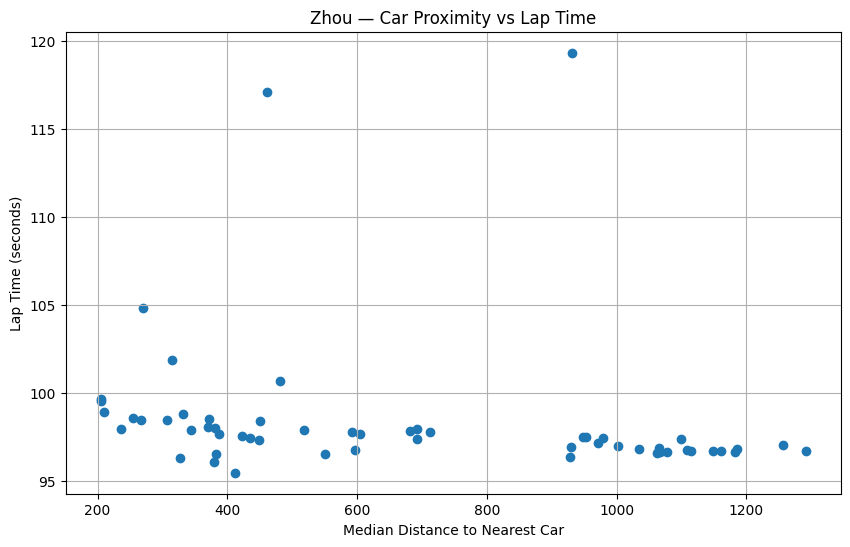

In [131]:
plt.figure(figsize=(10, 6))

plt.scatter(
    lap_traffic["MedianDistance"],
    lap_traffic["LapTimeSeconds"]
)

plt.xlabel("Median Distance to Nearest Car")
plt.ylabel("Lap Time (seconds)")
plt.title("Zhou — Car Proximity vs Lap Time")
plt.grid(True)

plt.show()

In [132]:
clean_lap_traffic = lap_traffic[
    ~lap_traffic["LapNumber"].isin([1, 9, 10, 28, 29])
].copy()


In [133]:
lap_traffic["LapNumber"].isin([1, 9, 10, 28, 29])


0      True
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8      True
9      True
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27     True
28     True
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50    False
51    False
52    False
53    False
54    False
55    False
Name: LapNumber, dtype: bool

In [134]:
clean_lap_traffic.shape

(51, 3)

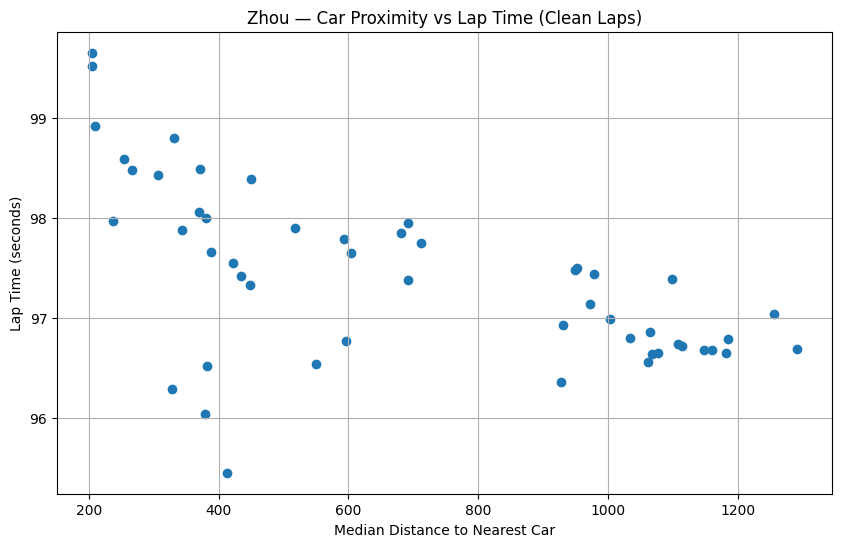

In [135]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_lap_traffic["MedianDistance"],
    clean_lap_traffic["LapTimeSeconds"]
)

plt.xlabel("Median Distance to Nearest Car")
plt.ylabel("Lap Time (seconds)")
plt.title("Zhou — Car Proximity vs Lap Time (Clean Laps)")
plt.grid(True)

plt.show()

In [136]:
clean_lap_traffic[["MedianDistance", "LapTimeSeconds"]].corr()

,MedianDistance,LapTimeSeconds
MedianDistance,1.000000,-0.580287
LapTimeSeconds,-0.580287,1.000000


In [137]:
# C4.2 --> # if we judge on the basis of the traffic vs the lap time we arwe getting the answwer according tot
# # this graph is that the greater the distance the better the lap time.

NOW WE ARE MOVING FORWARD WITH THE C4.3 SECTION - RACE CONTION VS THE LAP TIME

In [138]:
f1_data.track_status.head(20)

# f1_data.track_status["Message"].value_counts()

,Time,Status,Message
0,0 days 00:10:06.010000,1,AllClear
1,0 days 01:00:16.400000,2,Yellow
2,0 days 01:00:20.890000,1,AllClear
3,0 days 01:00:46.461000,2,Yellow
4,0 days 01:00:53.481000,1,AllClear
5,0 days 01:15:24.819000,2,Yellow
6,0 days 01:16:15.962000,1,AllClear


In [139]:
zhou_pos

,Date,Status,X,Y,Z,Source,Time,SessionTime
0,2024-03-02 14:03:43.899,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:01.468000,0 days 00:00:01.468000
1,2024-03-02 14:03:44.219,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:01.788000,0 days 00:00:01.788000
2,2024-03-02 14:03:44.460,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.029000,0 days 00:00:02.029000
3,2024-03-02 14:03:44.720,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.289000,0 days 00:00:02.289000
4,2024-03-02 14:03:45.000,OnTrack,0.0,0.0,0.0,pos,0 days 00:00:02.569000,0 days 00:00:02.569000
...,...,...,...,...,...,...,...,...
35989,2024-03-02 16:39:15.699,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.268000,0 days 02:35:33.268000
35990,2024-03-02 16:39:15.859,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.428000,0 days 02:35:33.428000
35991,2024-03-02 16:39:15.979,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.548000,0 days 02:35:33.548000
35992,2024-03-02 16:39:16.179,OnTrack,-246.0,844.0,-159.0,pos,0 days 02:35:33.748000,0 days 02:35:33.748000


In [140]:
f1_data.track_status[f1_data.track_status['Message'] == 'Yellow']

,Time,Status,Message
1,0 days 01:00:16.400000,2,Yellow
3,0 days 01:00:46.461000,2,Yellow
5,0 days 01:15:24.819000,2,Yellow


In [141]:
zhou_laps[
    ["LapNumber", "LapStartTime", "LapTimeSeconds"]
].head()

,LapNumber,LapStartTime,LapTimeSeconds
570,1.0,0 days 00:59:59.911000,104.801
571,2.0,0 days 01:01:45.006000,98.920
572,3.0,0 days 01:03:23.926000,98.582
573,4.0,0 days 01:05:02.508000,98.428
574,5.0,0 days 01:06:40.936000,98.798


In [142]:
yellow_status = f1_data.track_status[f1_data.track_status["Message"] == "Yellow"].copy()
yellow_status

,Time,Status,Message
1,0 days 01:00:16.400000,2,Yellow
3,0 days 01:00:46.461000,2,Yellow
5,0 days 01:15:24.819000,2,Yellow


In [143]:
race_condition_laps =pd.merge_asof(
    yellow_status.sort_values("Time"),
    zhou_laps[
        ["LapStartTime", "LapNumber", "LapTimeSeconds"]
    ].sort_values("LapStartTime"),
    left_on="Time",
    right_on="LapStartTime",
    direction="backward"
)

race_condition_laps

,Time,Status,Message,LapStartTime,LapNumber,LapTimeSeconds
0,0 days 01:00:16.400000,2,Yellow,0 days 00:59:59.911000,1.0,104.801
1,0 days 01:00:46.461000,2,Yellow,0 days 00:59:59.911000,1.0,104.801
2,0 days 01:15:24.819000,2,Yellow,0 days 01:14:59.234000,10.0,119.328


In [144]:
f1_data.track_status

,Time,Status,Message
0,0 days 00:10:06.010000,1,AllClear
1,0 days 01:00:16.400000,2,Yellow
2,0 days 01:00:20.890000,1,AllClear
3,0 days 01:00:46.461000,2,Yellow
4,0 days 01:00:53.481000,1,AllClear
5,0 days 01:15:24.819000,2,Yellow
6,0 days 01:16:15.962000,1,AllClear


In [145]:
yellow_intervals = f1_data.track_status[
    f1_data.track_status["Message"].isin(["Yellow", "AllClear"])
].copy()

yellow_intervals["EndTime"] = yellow_intervals["Time"].shift(-1)

yellow_intervals = yellow_intervals[
    yellow_intervals["Message"] == "Yellow"
][["Time", "EndTime"]]

yellow_intervals




,Time,EndTime
1,0 days 01:00:16.400000,0 days 01:00:20.890000
3,0 days 01:00:46.461000,0 days 01:00:53.481000
5,0 days 01:15:24.819000,0 days 01:16:15.962000


In [146]:
zhou_laps["LapEndTime"] = (
    zhou_laps["LapStartTime"] +
    pd.to_timedelta(zhou_laps["LapTimeSeconds"], unit="s")
)

zhou_laps["YellowAffected"] = False

for _, yellow in yellow_intervals.iterrows():

    overlap = (
        (zhou_laps["LapStartTime"] <= yellow["EndTime"]) &
        (zhou_laps["LapEndTime"] >= yellow["Time"])
    )

    zhou_laps.loc[overlap, "YellowAffected"] = True

In [164]:
zhou_laps[
    ["LapNumber", "LapTimeSeconds", "YellowAffected","LapEndTime",]
].head()



,LapNumber,LapTimeSeconds,YellowAffected,LapEndTime
570,1.0,104.801,True,0 days 01:01:44.712000
571,2.0,98.920,False,0 days 01:03:23.926000
572,3.0,98.582,False,0 days 01:05:02.508000
573,4.0,98.428,False,0 days 01:06:40.936000
574,5.0,98.798,False,0 days 01:08:19.734000


In [158]:
yellow_intervals

,Time,EndTime
1,0 days 01:00:16.400000,0 days 01:00:20.890000
3,0 days 01:00:46.461000,0 days 01:00:53.481000
5,0 days 01:15:24.819000,0 days 01:16:15.962000


,temp_duration,zhou_lap_time
570,0 days 00:01:44.801000,104.801
571,0 days 00:01:38.920000,98.920
572,0 days 00:01:38.582000,98.582
573,0 days 00:01:38.428000,98.428
574,0 days 00:01:38.798000,98.798
575,0 days 00:01:38.488000,98.488
576,0 days 00:01:39.517000,99.517
577,0 days 00:01:39.646000,99.646
578,0 days 00:01:41.849000,101.849
579,0 days 00:01:59.328000,119.328


In [165]:
zhou_laps.groupby("YellowAffected")["LapTimeSeconds"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
YellowAffected,,,
False,54,97.914296,97.4265
True,2,112.064500,112.0645


race condition may affect many drivers as the yellow double yellow and the safety cars have any 
impact with the race pace and some condition my be and opportunity for us and in some condition 
it might be and adv for the opponent so yes it defineitly affectt the over all race .


# ----------------------------- C4.4 TRACK AND WEATHER CONDITIONS --------------------------------

In [207]:
f1_data.weather_data

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:14.093000,18.9,46.0,1017.1,False,26.5,162,0.9
1,0 days 00:01:14.084000,18.9,46.0,1017.0,False,26.5,55,1.0
2,0 days 00:02:14.093000,18.9,46.0,1017.0,False,26.5,55,1.0
3,0 days 00:03:14.090000,18.9,45.0,1017.0,False,26.2,85,1.1
4,0 days 00:04:14.091000,18.9,46.0,1017.0,False,26.2,178,1.0
...,...,...,...,...,...,...,...,...
152,0 days 02:32:14.300000,17.6,51.0,1017.5,False,21.9,0,0.7
153,0 days 02:33:14.300000,17.6,51.0,1017.5,False,21.9,271,0.0
154,0 days 02:34:14.313000,17.7,51.0,1017.5,False,21.9,0,0.4
155,0 days 02:35:14.305000,17.6,51.0,1017.5,False,21.9,257,0.0


In [208]:
zhou_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSeconds', 'PositionChange',
       'PitLap', 'LapEndTime', 'YellowAffected'],
      dtype='object')

In [209]:
zhou_laps.head(10)[['LapStartTime','LapEndTime']]

,LapStartTime,LapEndTime
570,0 days 00:59:59.911000,0 days 01:01:44.712000
571,0 days 01:01:45.006000,0 days 01:03:23.926000
572,0 days 01:03:23.926000,0 days 01:05:02.508000
573,0 days 01:05:02.508000,0 days 01:06:40.936000
574,0 days 01:06:40.936000,0 days 01:08:19.734000
575,0 days 01:08:19.734000,0 days 01:09:58.222000
576,0 days 01:09:58.222000,0 days 01:11:37.739000
577,0 days 01:11:37.739000,0 days 01:13:17.385000
578,0 days 01:13:17.385000,0 days 01:14:59.234000
579,0 days 01:14:59.234000,0 days 01:16:58.562000


In [210]:
# print(zhou_laps[['LapStartTime','LapEndTime','LapNumber']])
# print(f1_data.weather_data['Time'].head)


# temp_df = pd.DataFrame({
#     'weatherTime': f1_data.weather_data["Time"] ,
#     'LapStartTime':zhou_laps['LapStartTime'],
#     'LapEndTime':zhou_laps['LapEndTime'], 
#     'LapNumber' : zhou_laps['LapNumber']
    

# })


# weather_data = temp_df.dropna()

# weather_data



# # temp_df[temp_df['LapStartTime'] >= 0 days 00:59:59.911000]

# temp_df



problem :
solution :

In [212]:
weather_data = f1_data.weather_data.copy()
weather_data["LapNumber"] = pd.NA

In [237]:
for _, lap in zhou_laps.iterrows():

    mask = (
        (weather_data["Time"] >= lap["LapStartTime"]) &
        (weather_data["Time"] < lap["LapEndTime"])
    )

    # print(mask.notnull())

    weather_data.loc[mask, "LapNumber"] = lap["LapNumber"]

weather_data[weather_data['LapNumber'].notnull()]

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,LapNumber
60,0 days 01:00:14.115000,18.2,49.0,1017.2,False,23.8,58,1.5,1.0
61,0 days 01:01:14.131000,18.3,49.0,1017.0,False,23.8,28,0.9,1.0
62,0 days 01:02:14.121000,18.3,49.0,1017.0,False,23.8,33,1.1,2.0
63,0 days 01:03:14.127000,18.3,49.0,1017.1,False,23.8,89,1.5,2.0
64,0 days 01:04:14.121000,18.3,49.0,1017.0,False,23.8,32,1.0,3.0
...,...,...,...,...,...,...,...,...,...
147,0 days 02:27:14.309000,17.6,51.0,1017.5,False,21.9,213,0.3,54.0
148,0 days 02:28:14.305000,17.6,51.0,1017.5,False,21.9,0,0.3,54.0
149,0 days 02:29:14.305000,17.6,51.0,1017.5,False,21.9,12,0.0,55.0
150,0 days 02:30:14.302000,17.6,51.0,1017.5,False,21.9,115,0.4,55.0


In [215]:
weather_lap = (
    weather_data.dropna(subset=["LapNumber"])
    .groupby("LapNumber")
    .agg(
        AvgAirTemp=("AirTemp", "mean"),
        AvgHumidity=("Humidity", "mean"),
        AvgPressure=("Pressure", "mean"),
        AvgTrackTemp=("TrackTemp", "mean"),
        AvgWindSpeed=("WindSpeed", "mean"),
        AvgWindDirection=("WindDirection", "mean"),
        RainDuringLap=("Rainfall", "any")
    )
    .reset_index()
)

In [ ]:
weather_lap

In [245]:
zhou_weather = zhou_laps.merge(
    weather_lap,
    on="LapNumber",
    how="left"
)

zhou_weather.columns

temp_weather_data = zhou_weather[['LapNumber','Stint','Compound','TyreLife','Position','LapTimeSeconds','AvgAirTemp','AvgHumidity','AvgPressure','AvgTrackTemp','AvgWindSpeed','AvgWindDirection','RainDuringLap']]

temp_weather_data.describe()

,LapNumber,Stint,TyreLife,Position,LapTimeSeconds,AvgAirTemp,AvgHumidity,AvgPressure,AvgTrackTemp,AvgWindSpeed,AvgWindDirection
count,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,28.500000,2.339286,11.446429,11.910714,98.419661,18.005357,49.928571,1017.278571,22.813393,0.521429,105.294643
std,16.309506,0.745332,7.546028,2.011574,4.119505,0.210557,0.716231,0.155755,0.618392,0.315055,100.040391
min,1.000000,1.000000,1.000000,9.000000,95.458000,17.600000,49.000000,1017.000000,21.900000,0.000000,0.000000
25%,14.750000,2.000000,5.000000,10.750000,96.735750,17.900000,49.000000,1017.150000,22.312500,0.350000,32.750000
50%,28.500000,2.500000,10.000000,11.000000,97.459000,18.050000,50.000000,1017.250000,22.775000,0.550000,74.750000
75%,42.250000,3.000000,17.000000,13.000000,98.137000,18.112500,50.000000,1017.400000,23.400000,0.700000,142.500000
max,56.000000,3.000000,28.000000,17.000000,119.328000,18.300000,51.000000,1017.500000,23.800000,1.300000,356.000000


EDA for the weather vs lap time , tyre , race progression

In [ ]:
# WEATHER - LAP TINE 

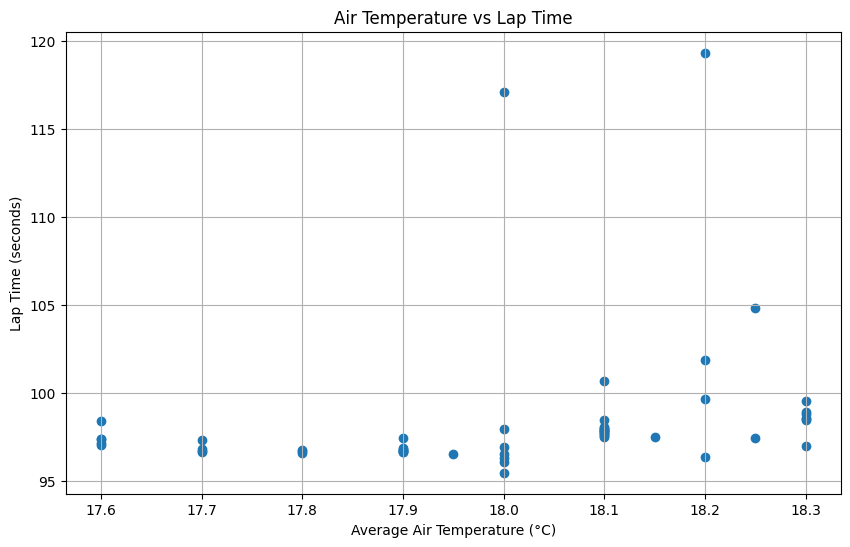

In [246]:
plt.figure(figsize=(10, 6))

plt.scatter(
    temp_weather_data["AvgAirTemp"],
    temp_weather_data["LapTimeSeconds"]
)

plt.xlabel("Average Air Temperature (°C)")
plt.ylabel("Lap Time (seconds)")
plt.title("Air Temperature vs Lap Time")
plt.grid(True)

plt.show()

In [ ]:
# usuall its constant through out the race for the air temp

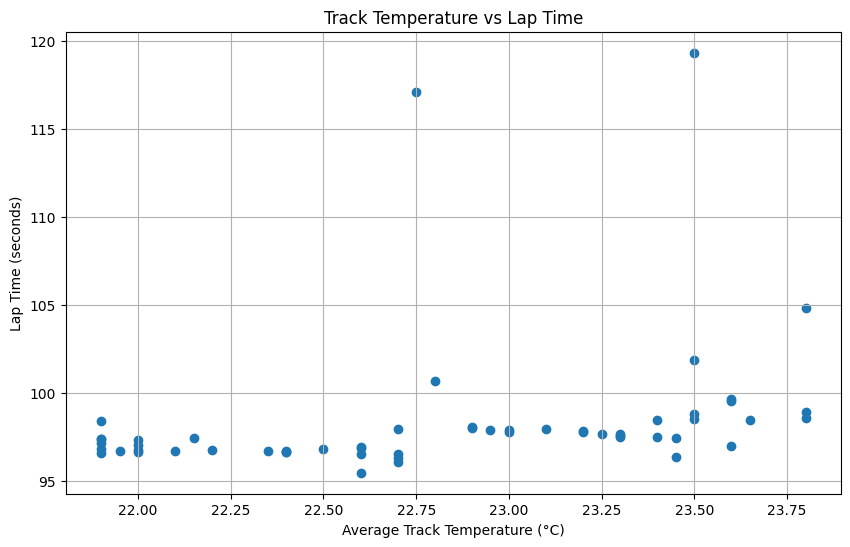

In [247]:
plt.figure(figsize=(10, 6))

plt.scatter(
    temp_weather_data["AvgTrackTemp"],
    temp_weather_data["LapTimeSeconds"]
)

plt.xlabel("Average Track Temperature (°C)")
plt.ylabel("Lap Time (seconds)")
plt.title("Track Temperature vs Lap Time")
plt.grid(True)

plt.show()

In [ ]:
yes the lap time increase when the track temp increased i jst judging the graph there are other many factors such as the trafic , fuel weirght etc 

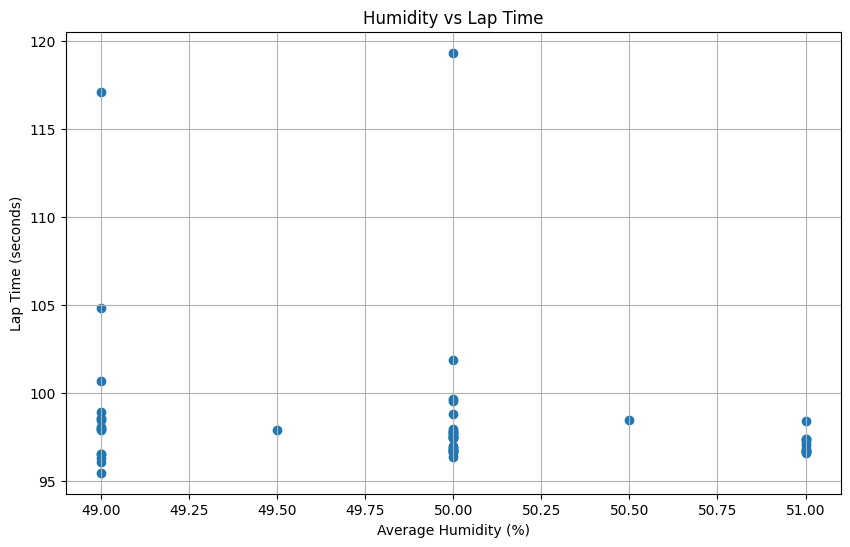

In [249]:
plt.figure(figsize=(10, 6))

plt.scatter(
    temp_weather_data["AvgHumidity"],
    temp_weather_data["LapTimeSeconds"]
)

plt.xlabel("Average Humidity (%)")
plt.ylabel("Lap Time (seconds)")
plt.title("Humidity vs Lap Time")
plt.grid(True)

plt.show()

In [ ]:
# quite constant and normal

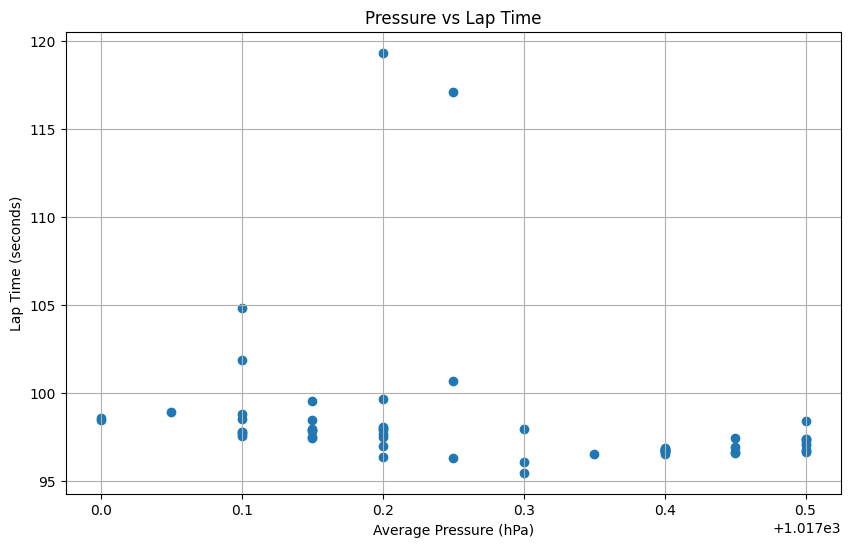

In [250]:
plt.figure(figsize=(10, 6))

plt.scatter(
    temp_weather_data["AvgPressure"],
    temp_weather_data["LapTimeSeconds"]
)

plt.xlabel("Average Pressure (hPa)")
plt.ylabel("Lap Time (seconds)")
plt.title("Pressure vs Lap Time")
plt.grid(True)

plt.show()

In [ ]:
# presuure increase lap time decresses

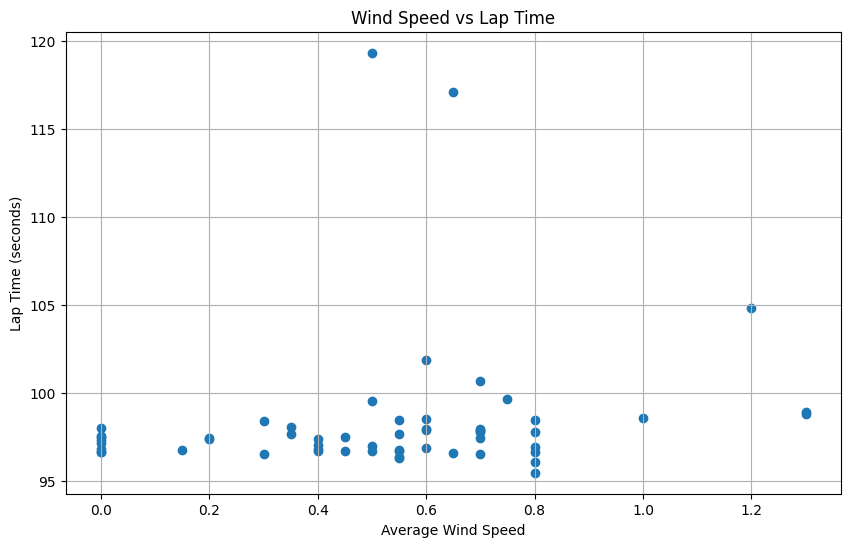

In [251]:
plt.figure(figsize=(10, 6))

plt.scatter(
    temp_weather_data["AvgWindSpeed"],
    temp_weather_data["LapTimeSeconds"]
)

plt.xlabel("Average Wind Speed")
plt.ylabel("Lap Time (seconds)")
plt.title("Wind Speed vs Lap Time")
plt.grid(True)

plt.show()

In [ ]:
# wind speed is quite random

In [ ]:
# EDA FOR WEATHET TO TYRE LIFE 

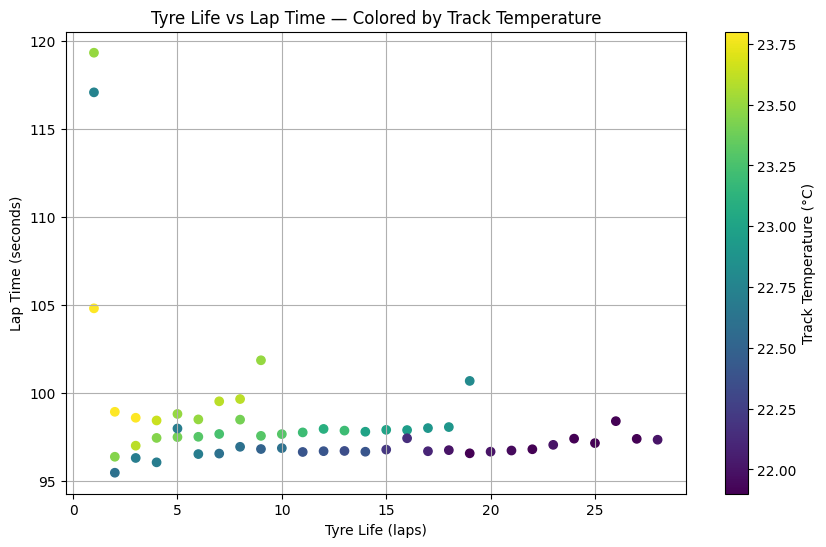

In [253]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    temp_weather_data["TyreLife"],
    temp_weather_data["LapTimeSeconds"],
    c=temp_weather_data["AvgTrackTemp"],
    cmap="viridis"
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Life vs Lap Time — Colored by Track Temperature")

plt.colorbar(scatter, label="Track Temperature (°C)")
plt.grid(True)

plt.show()

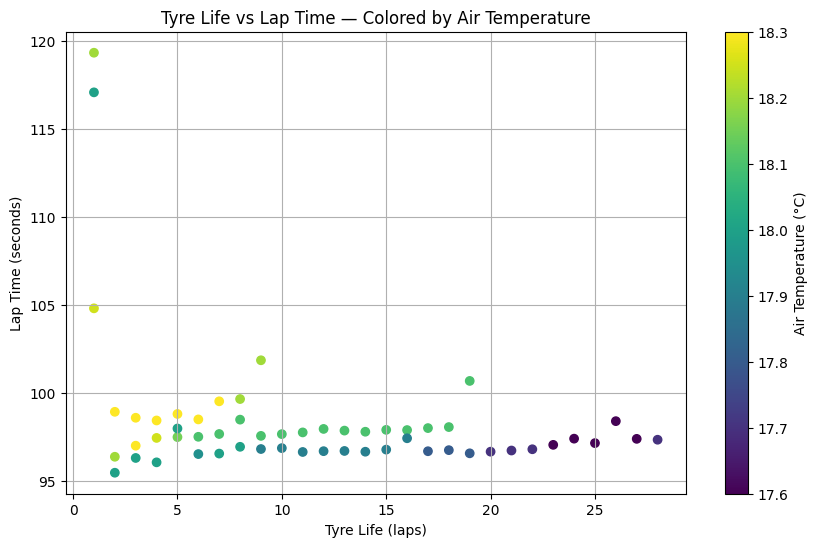

In [254]:
# TYRE LIFE + AIR TEMP + LAP TIME

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    temp_weather_data["TyreLife"],
    temp_weather_data["LapTimeSeconds"],
    c=temp_weather_data["AvgAirTemp"],
    cmap="viridis"
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Life vs Lap Time — Colored by Air Temperature")

plt.colorbar(scatter, label="Air Temperature (°C)")
plt.grid(True)

plt.show()

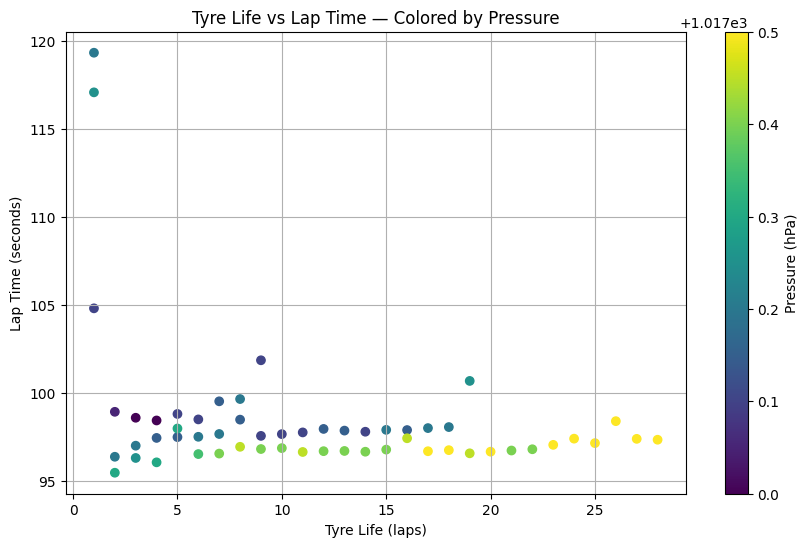

In [255]:
# Tyre Life + Pressure + Lap Time

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    temp_weather_data["TyreLife"],
    temp_weather_data["LapTimeSeconds"],
    c=temp_weather_data["AvgPressure"],
    cmap="viridis"
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Life vs Lap Time — Colored by Pressure")

plt.colorbar(scatter, label="Pressure (hPa)")
plt.grid(True)

plt.show()


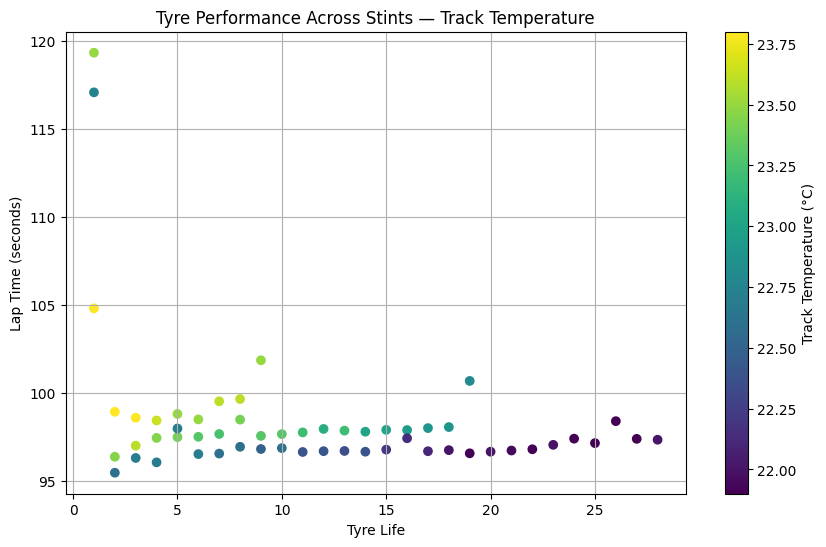

In [256]:
# Stint + Lap Time + Track Temperature


plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    temp_weather_data["TyreLife"],
    temp_weather_data["LapTimeSeconds"],
    c=temp_weather_data["AvgTrackTemp"],
    cmap="viridis"
)

plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (seconds)")
plt.title("Tyre Performance Across Stints — Track Temperature")

plt.colorbar(scatter, label="Track Temperature (°C)")
plt.grid(True)

plt.show()

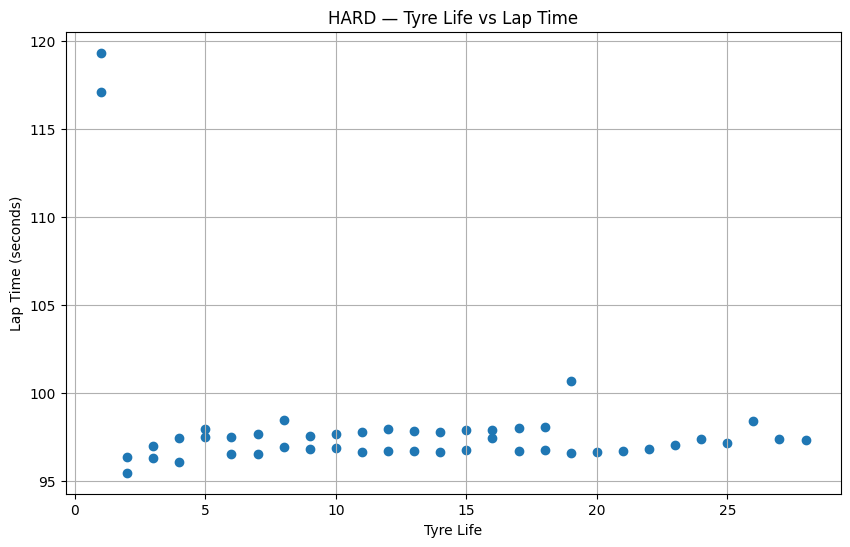

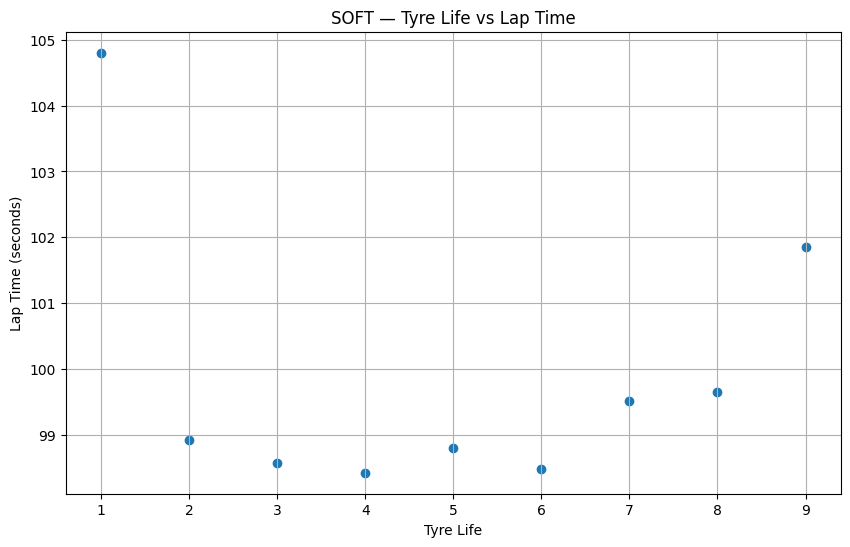

In [257]:
for compound, data in temp_weather_data.groupby("Compound"):

    plt.figure(figsize=(10, 6))

    plt.scatter(
        data["TyreLife"],
        data["LapTimeSeconds"]
    )

    plt.xlabel("Tyre Life")
    plt.ylabel("Lap Time (seconds)")
    plt.title(f"{compound} — Tyre Life vs Lap Time")
    plt.grid(True)

    plt.show()

In [ ]:
# Compound → Weather → Lap Time ⭐

for compound, data in temp_weather_data.groupby("Compound"):

    plt.figure(figsize=(10, 6))

    plt.scatter(
        data["AvgTrackTemp"],
        data["LapTimeSeconds"]
    )

    plt.xlabel("Average Track Temperature (°C)")
    plt.ylabel("Lap Time (seconds)")
    plt.title(f"{compound} — Track Temperature vs Lap Time")
    plt.grid(True)

    plt.show()